<a href="https://colab.research.google.com/github/Miguithub/SpotV2Net/blob/main/Wavelets_VOL_BTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# LIBRERIAS 1

In [ ]:
!pip install statsmodels

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

# DE

In [ ]:
btc = pd.read_parquet('/content/drive/MyDrive/mf12024.parquet')

In [ ]:
# eth = pd.read_parquet('/content/drive/MyDrive/1meth.parquet')

In [ ]:
# sol = pd.read_parquet('/content/drive/MyDrive/1msol.parquet')

Check

In [ ]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31622400 entries, 0 to 31622399
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   open_time               int64  
 1   open                    float64
 2   high                    float64
 3   low                     float64
 4   close                   float64
 5   volume                  float64
 6   close_time              int64  
 7   quote_volume            float64
 8   trade_count             int64  
 9   taker_buy_base_volume   float64
 10  taker_buy_quote_volume  float64
 11  ignore                  int64  
dtypes: float64(8), int64(4)
memory usage: 2.8 GB


In [ ]:
btc.tail()

,open_time,open,high,low,close,volume,close_time,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume,ignore
31622395,1735689595000,93576.00,93576.01,93576.00,93576.01,0.00083,1735689595999,77.668087,2,0.00067,62.695927,0
31622396,1735689596000,93576.01,93576.01,93576.01,93576.01,0.00000,1735689596999,0.000000,0,0.00000,0.000000,0
31622397,1735689597000,93576.01,93576.01,93576.01,93576.01,0.00000,1735689597999,0.000000,0,0.00000,0.000000,0
31622398,1735689598000,93576.01,93576.01,93576.01,93576.01,0.00094,1735689598999,87.961449,3,0.00094,87.961449,0
31622399,1735689599000,93576.00,93576.00,93576.00,93576.00,0.00217,1735689599999,203.059920,3,0.00000,0.000000,0


In [ ]:
btc.head()

,open_time,open,high,low,close,volume,close_time,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume,ignore
0,1704067200000,42283.58,42283.59,42283.58,42283.58,0.07625,1704067200999,3224.123141,21,0.01658,701.061922,0
1,1704067201000,42283.59,42283.59,42283.58,42283.58,1.37528,1704067201999,58151.769471,51,0.75683,32001.489420,0
2,1704067202000,42283.58,42283.59,42283.58,42283.58,0.18867,1704067202999,7977.643051,9,0.00124,52.431652,0
3,1704067203000,42283.58,42283.59,42283.58,42283.59,0.83488,1704067203999,35301.720464,39,0.51935,21959.982467,0
4,1704067204000,42283.58,42283.59,42283.58,42283.59,0.23809,1704067204999,10067.297927,17,0.03653,1544.619543,0


Cleaness

In [ ]:
import pandas as pd

# Usá el nombre real de tu columna temporal
t = pd.to_datetime(btc["close_time"])

# diferencias entre timestamps en segundos
d = t.diff().dt.total_seconds()

# chequeo de equidistancia
es_equidistante = d.iloc[1:].nunique() == 1

print("Equidistante:", es_equidistante)
print("Intervalo único (segundos):", d.iloc[1] if es_equidistante else "No uniforme")

Equidistante: True
Intervalo único (segundos): 1e-06


In [ ]:
del t, d
import gc
gc.collect()

17

In [ ]:
btc.drop(columns=btc.columns[0], inplace=True)
btc["time"] = pd.to_datetime(btc["close_time"] // 1000, unit="s")
cols = ["time"] + [c for c in btc.columns if c not in ["time", "close_time"]]
btc = btc[cols]

In [ ]:
btc["day"] = btc["time"].dt.weekday + 1
btc.loc[btc["day"] == 7, "day"] = 0

In [ ]:
btc.tail()

,time,open,high,low,close,volume,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume,ignore,day
31622395,2024-12-31 23:59:55,93576.00,93576.01,93576.00,93576.01,0.00083,77.668087,2,0.00067,62.695927,0,2
31622396,2024-12-31 23:59:56,93576.01,93576.01,93576.01,93576.01,0.00000,0.000000,0,0.00000,0.000000,0,2
31622397,2024-12-31 23:59:57,93576.01,93576.01,93576.01,93576.01,0.00000,0.000000,0,0.00000,0.000000,0,2
31622398,2024-12-31 23:59:58,93576.01,93576.01,93576.01,93576.01,0.00094,87.961449,3,0.00094,87.961449,0,2
31622399,2024-12-31 23:59:59,93576.00,93576.00,93576.00,93576.00,0.00217,203.059920,3,0.00000,0.000000,0,2


In [ ]:
cols = ["time", "day"] + [c for c in btc.columns if c not in ["time", "day"]]
btc = btc[cols]

In [ ]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31622400 entries, 0 to 31622399
Data columns (total 12 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   time                    datetime64[ns]
 1   day                     int64         
 2   open                    float64       
 3   high                    float64       
 4   low                     float64       
 5   close                   float64       
 6   volume                  float64       
 7   quote_volume            float64       
 8   trade_count             int64         
 9   taker_buy_base_volume   float64       
 10  taker_buy_quote_volume  float64       
 11  ignore                  int64         
dtypes: datetime64[ns](1), float64(8), int64(3)
memory usage: 2.8 GB


# Vol Parametric

In [ ]:
vp_btc = btc.iloc[:, [0, 1, 5]]

In [ ]:
vp_btc["close_ln"] = np.log(vp_btc["close"])
vp_btc["r"] = vp_btc["close_ln"].diff()

/tmp/ipython-input-3468037127.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vp_btc["close_ln"] = np.log(vp_btc["close"])
/tmp/ipython-input-3468037127.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vp_btc["r"] = vp_btc["close_ln"].diff()


In [ ]:
# Definir las ventanas para calcular volatilidad (datos en segundos)
ventanas_vol = {
    "5s": 5,
    "10s": 10,
    "15s": 15,
    "20s": 20,
    "30s": 30,
    "45s": 45,
    "1m": 60,
    "90s": 90,
    "2m": 120,
    "5m": 300,
    "10m": 600,
    "15m": 900,
    "16m": 960,
    "20m": 1200,
    "30m": 1800,
    "45m": 2700,
    "1h": 3600,
    "2h": 7200,
    "3h": 10800,
    "6h": 21600,
    "8h": 28800,
    "12h": 43200,
    "1d": 86400,
    "2d": 172800,
    "3d": 259200,
    "5d": 432000,
    "1w": 604800,
    "2w": 1209600,
    "1m": 3024000,
    "2m": 6048000,
    "3m": 9072000
}

for nombre, ventana in ventanas_vol.items():
    sd_col = f"SD_{ventana}"
    vb_col = f"VB{nombre}"

    vp_btc[sd_col] = vp_btc["r"].rolling(window=ventana, min_periods=ventana).std()
    vp_btc[vb_col] = vp_btc[sd_col] * np.sqrt(ventana)

/tmp/ipython-input-2998249722.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vp_btc[sd_col] = vp_btc["r"].rolling(window=ventana, min_periods=ventana).std()
/tmp/ipython-input-2998249722.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vp_btc[vb_col] = vp_btc[sd_col] * np.sqrt(ventana)
/tmp/ipython-input-2998249722.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

In [ ]:
vp_btc.info()

In [ ]:
vp_btc.tail()

,time,day,close,close_ln,r,SD_5,VB5s,SD_10,VB10s,SD_15,...,SD_259200,VB3d,SD_432000,VB5d,SD_604800,VB1s,SD_1209600,VB2s,SD_9072000,VB3m
31622395,2024-12-31 23:59:55,2,93576.01,11.446529,1.068650e-07,8.940958e-08,1.999259e-07,7.124329e-08,2.252911e-07,6.995960e-08,...,0.000065,0.03329,0.000064,0.041876,0.000064,0.049742,0.000081,0.088745,0.000072,0.215364
31622396,2024-12-31 23:59:56,2,93576.01,11.446529,0.000000e+00,8.940958e-08,1.999259e-07,7.124329e-08,2.252911e-07,6.995960e-08,...,0.000065,0.03329,0.000064,0.041876,0.000064,0.049742,0.000081,0.088745,0.000072,0.215364
31622397,2024-12-31 23:59:57,2,93576.01,11.446529,0.000000e+00,8.940958e-08,1.999259e-07,6.066146e-08,1.918284e-07,6.995960e-08,...,0.000065,0.03329,0.000064,0.041876,0.000064,0.049742,0.000081,0.088745,0.000072,0.215364
31622398,2024-12-31 23:59:58,2,93576.01,11.446529,0.000000e+00,7.556486e-08,1.689682e-07,6.066146e-08,1.918284e-07,6.343690e-08,...,0.000065,0.03329,0.000064,0.041876,0.000064,0.049742,0.000081,0.088745,0.000072,0.215364
31622399,2024-12-31 23:59:59,2,93576.00,11.446529,-1.068650e-07,7.556486e-08,1.689682e-07,7.124329e-08,2.252911e-07,6.995960e-08,...,0.000065,0.03329,0.000064,0.041876,0.000064,0.049742,0.000081,0.088745,0.000072,0.215364


## 5segs

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB1w","VB2w","VB1m","VB2m","VB3m"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB5s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB5s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
4     VB3m            0.000002
0     VB1w            0.000002
1     VB2w            0.000002
3     VB2m            0.000001
2     VB1m            0.000001


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB1d","VB2d","VB3d","VB5d"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB5s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB5s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
2     VB3d        1.264927e-06
1     VB2d        1.217492e-06
3     VB5d        1.106811e-06
0     VB1d        6.640868e-07


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB6h","VB8h","VB12h"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB5s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB5s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
2    VB12h        3.952899e-07
1     VB8h        2.213626e-07
0     VB6h        1.739278e-07


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB1h","VB2h","VB3h"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB5s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB5s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
2     VB3h        3.004205e-07
1     VB2h        2.055510e-07
0     VB1h        6.324677e-08


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB20m","VB30m","VB45m"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB5s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB5s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
1    VB30m        3.162320e-07
2    VB45m        2.055510e-07
0    VB20m        1.739278e-07


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB2m","VB5m","VB10m"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB5s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB5s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
0     VB2m        1.676028e-06
1     VB5m        1.739278e-07
2    VB10m        1.106815e-07


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB45s","VB1m","VB90s"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB5s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB5s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
1     VB1m        1.201680e-06
0    VB45s        1.581203e-08
2    VB90s        1.581203e-08


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB15s","VB20s","VB30s"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB5s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB5s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
1    VB20s        1.264931e-07
0    VB15s        1.581203e-08
2    VB30s        4.529710e-13


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB10s"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB5s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB5s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

ANALISIS VISUAL

Bloque elegido:
Inicio: 2024-12-28 00:54:21
Fin   : 2024-12-28 00:59:21


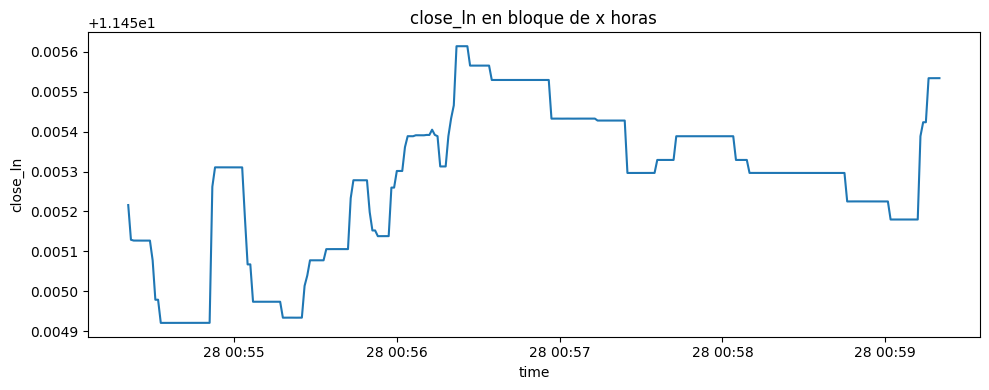

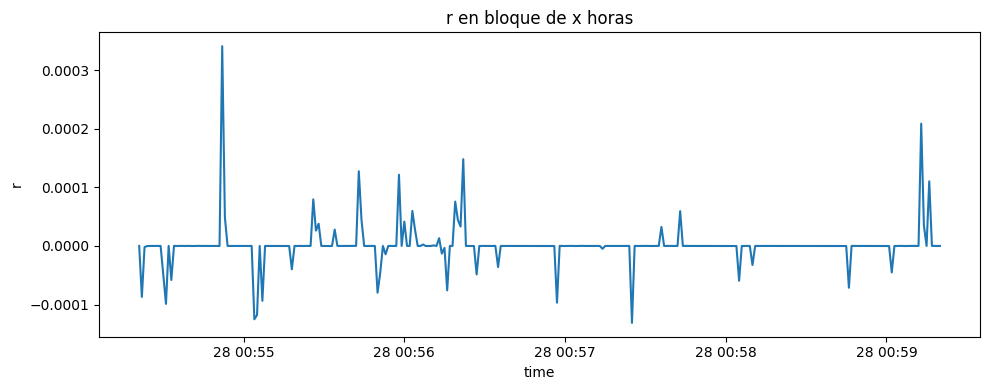

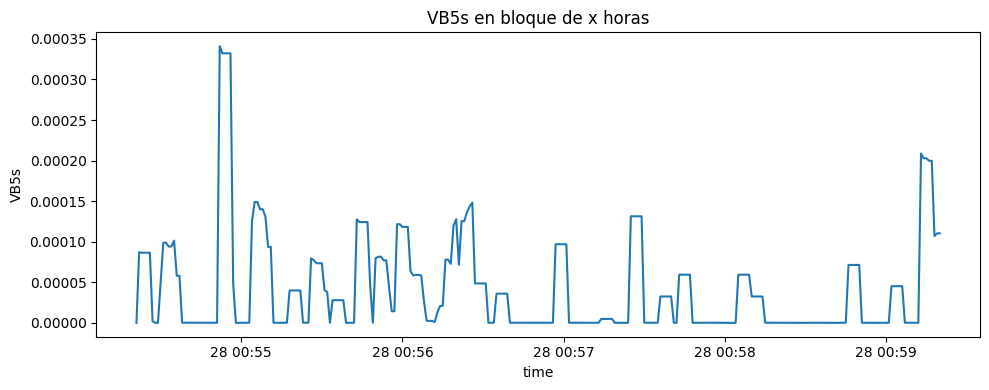

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
vp_btc["time"] = pd.to_datetime(vp_btc["time"])

# 1) Definir rango posible para elegir un bloque continuo de 8 horas
t_min = vp_btc["time"].min()
t_max = vp_btc["time"].max() - pd.Timedelta(hours=8)

# Elegir aleatoriamente un inicio dentro del rango
total_segundos = int((t_max - t_min).total_seconds())
offset_segundos = np.random.randint(0, total_segundos + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar solo las filas dentro de esas 8 horas continuas
mask = (vp_btc["time"] >= t_inicio) & (vp_btc["time"] < t_fin)
sub = vp_btc.loc[mask, ["time", "close_ln", "r", "VB5s"]].dropna()

# 3) Graficar las tres series en bloques separados

# 1) hs aleatorias y close_ln
plt.figure(figsize=(10, 4))
plt.plot(sub["time"], sub["close_ln"])
plt.title("close_ln en bloque de x horas")
plt.xlabel("time"); plt.ylabel("close_ln")
plt.tight_layout(); plt.show()

# 2) hs aleatorias y r
plt.figure(figsize=(10, 4))
plt.plot(sub["time"], sub["r"])
plt.title("r en bloque de x horas")
plt.xlabel("time"); plt.ylabel("r")
plt.tight_layout(); plt.show()

# 3) hs aleatorias y VB5s
plt.figure(figsize=(10, 4))
plt.plot(sub["time"], sub["VB5s"])
plt.title("VB5s en bloque de x horas")
plt.xlabel("time"); plt.ylabel("VB5s")
plt.tight_layout(); plt.show()

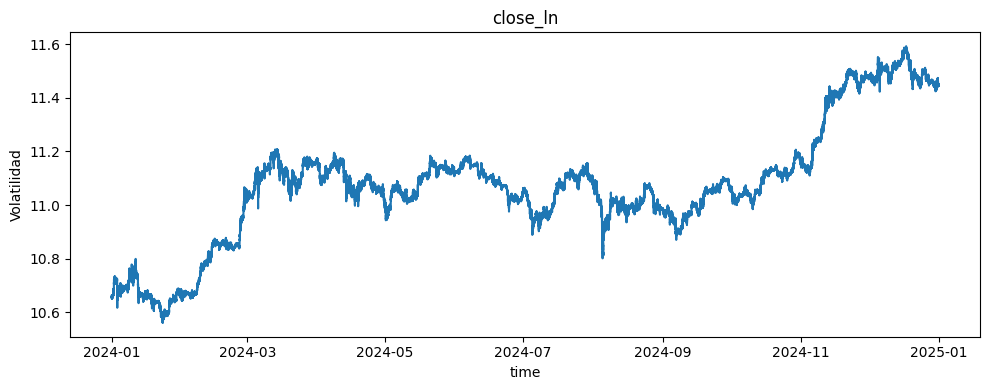

In [ ]:
s = vp_btc["close_ln"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(vp_btc.loc[s.index, "time"], s.values)
plt.title("close_ln")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

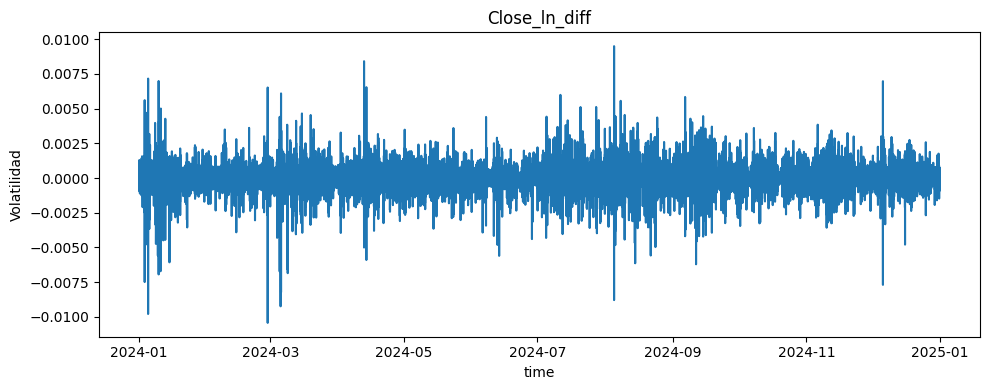

In [ ]:
s = vp_btc["r"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(vp_btc.loc[s.index, "time"], s.values)
plt.title("Close_ln_diff")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

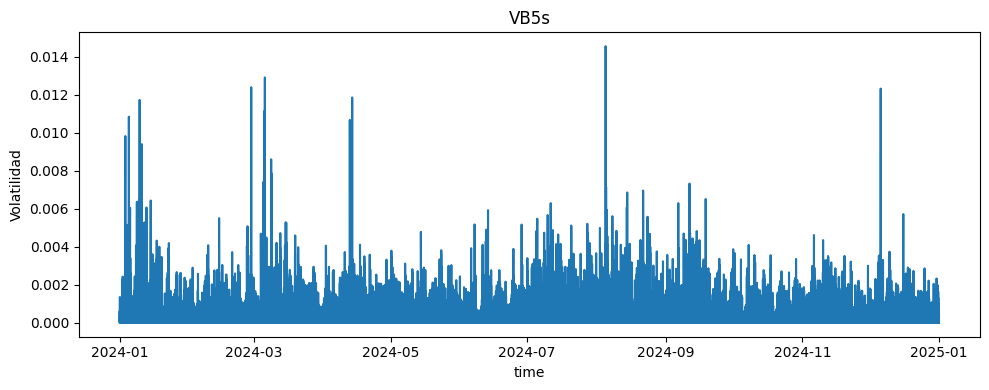

In [ ]:
s = vp_btc["VB5s"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(vp_btc.loc[s.index, "time"], s.values)
plt.title("VB5s")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

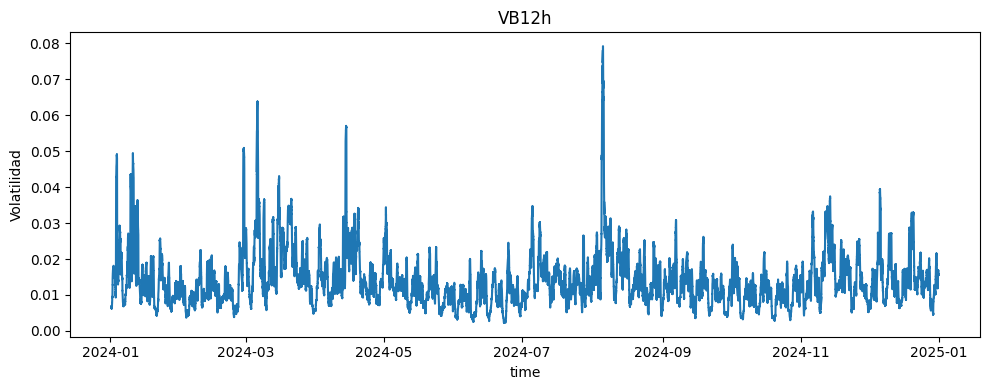

In [ ]:
s = vp_btc["VB12h"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(vp_btc.loc[s.index, "time"], s.values)
plt.title("VB12h")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

In [ ]:
# As we can see on the mutual information test and the theory of hf data, 5 seg use
# to be full of noise wich makes it so hard to understan and predict. Never the less, is
# good to say that above the mi results are ver bad vb5s has more mi with low frequencys:
# Variable  Mutual Information
# 4     VB3m            0.000002
# 0     VB1w            0.000002
# 1     VB2w            0.000002
# 3     VB2m            0.000001
# 2     VB1m            0.000001

# In hf, has its maximun value at 2 minutes
#   Variable  Mutual Information
# 0     VB2m        1.676028e-06
# 1     VB5m        1.739278e-07
# 2    VB10m        1.106815e-07

## 15segs

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB1w","VB2w","VB1m","VB2m","VB3m"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
3     VB2m            0.000002
4     VB3m            0.000002
2     VB1m            0.000002
0     VB1w            0.000002
1     VB2w            0.000002


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB1d","VB2d","VB3d","VB5d"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
0     VB1d        1.043563e-06
3     VB5d        9.645052e-07
2     VB3d        8.696357e-07
1     VB2d        8.538241e-07


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB6h","VB8h","VB12h"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
0     VB6h        3.636650e-07
2    VB12h        3.636650e-07
1     VB8h        2.371724e-07


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB1h","VB2h","VB3h"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
0     VB1h        2.371724e-07
2     VB3h        1.581144e-07
1     VB2h        1.423029e-07


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB20m","VB30m","VB45m"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
1    VB30m        3.162320e-07
2    VB45m        2.055510e-07
0    VB20m        1.739278e-07


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB2m","VB5m","VB10m"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
0     VB2m        1.676028e-06
1     VB5m        1.739278e-07
2    VB10m        1.106815e-07


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB45s","VB1m","VB90s"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
1     VB1m        1.296548e-06
0    VB45s        1.106797e-07
2    VB90s        9.486811e-08


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB30s"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
0    VB30s        6.324494e-08


ANALISIS VISUAL

Bloque elegido:
Inicio: 2024-12-28 00:54:21
Fin   : 2024-12-28 00:59:21


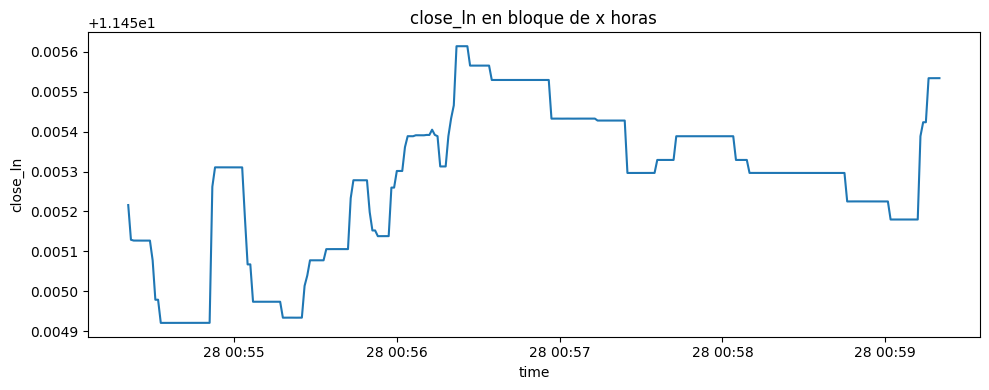

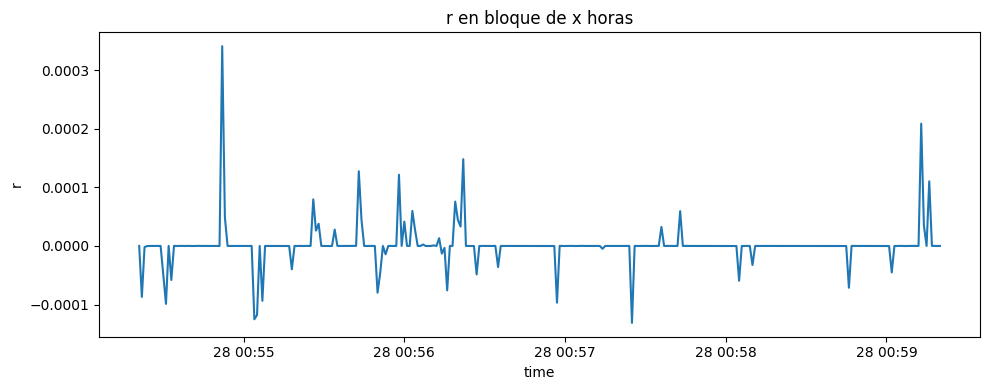

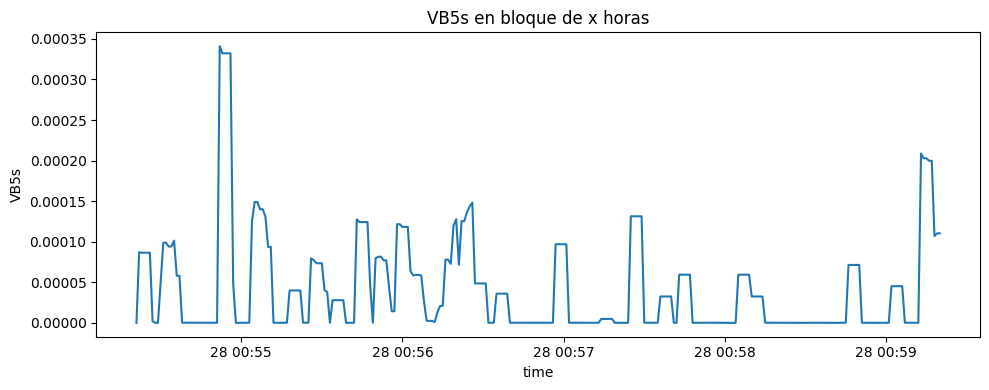

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
vp_btc["time"] = pd.to_datetime(vp_btc["time"])

# 1) Definir rango posible para elegir un bloque continuo de 8 horas
t_min = vp_btc["time"].min()
t_max = vp_btc["time"].max() - pd.Timedelta(hours=8)

# Elegir aleatoriamente un inicio dentro del rango
total_segundos = int((t_max - t_min).total_seconds())
offset_segundos = np.random.randint(0, total_segundos + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar solo las filas dentro de esas 8 horas continuas
mask = (vp_btc["time"] >= t_inicio) & (vp_btc["time"] < t_fin)
sub = vp_btc.loc[mask, ["time", "close_ln", "r", "VB5s"]].dropna()

# 3) Graficar las tres series en bloques separados

# 1) hs aleatorias y close_ln
plt.figure(figsize=(10, 4))
plt.plot(sub["time"], sub["close_ln"])
plt.title("close_ln en bloque de x horas")
plt.xlabel("time"); plt.ylabel("close_ln")
plt.tight_layout(); plt.show()

# 2) hs aleatorias y r
plt.figure(figsize=(10, 4))
plt.plot(sub["time"], sub["r"])
plt.title("r en bloque de x horas")
plt.xlabel("time"); plt.ylabel("r")
plt.tight_layout(); plt.show()

# 3) hs aleatorias y VB5s
plt.figure(figsize=(10, 4))
plt.plot(sub["time"], sub["VB5s"])
plt.title("VB5s en bloque de x horas")
plt.xlabel("time"); plt.ylabel("VB5s")
plt.tight_layout(); plt.show()

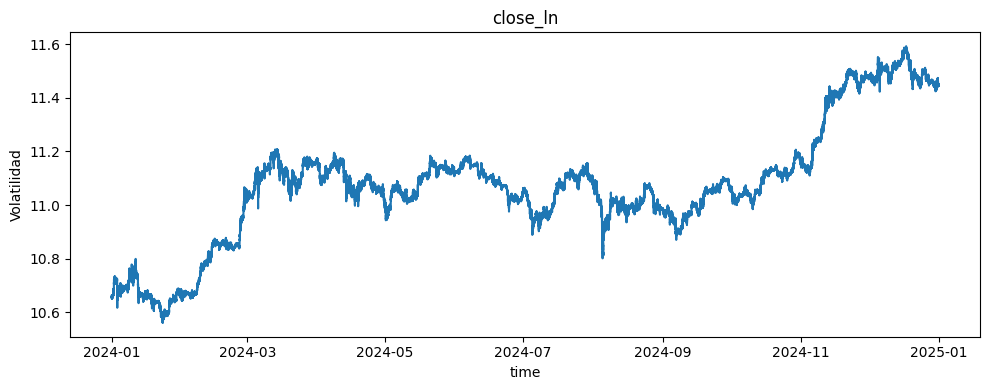

In [ ]:
s = vp_btc["close_ln"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(vp_btc.loc[s.index, "time"], s.values)
plt.title("close_ln")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

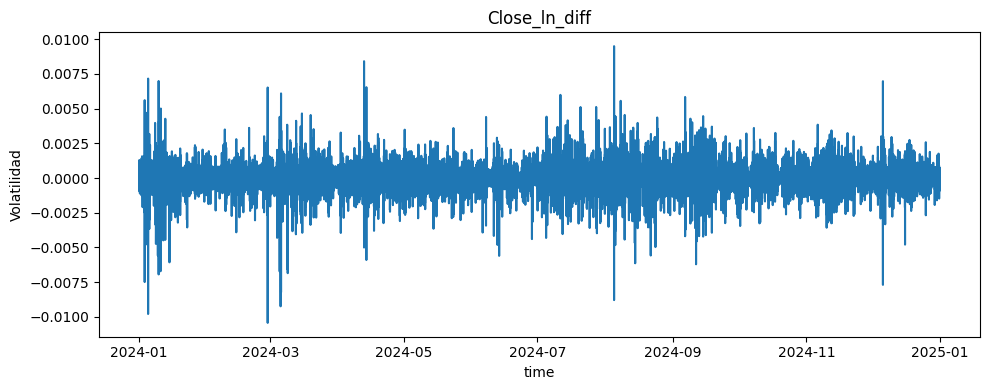

In [ ]:
s = vp_btc["r"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(vp_btc.loc[s.index, "time"], s.values)
plt.title("Close_ln_diff")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

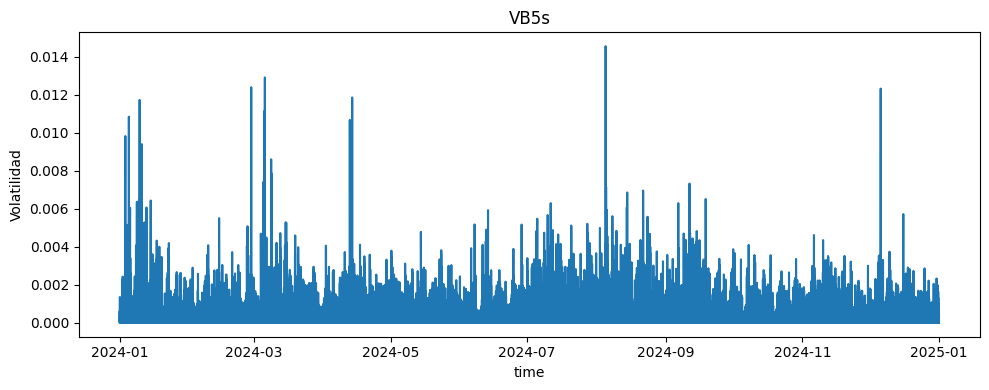

In [ ]:
s = vp_btc["VB5s"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(vp_btc.loc[s.index, "time"], s.values)
plt.title("VB5s")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

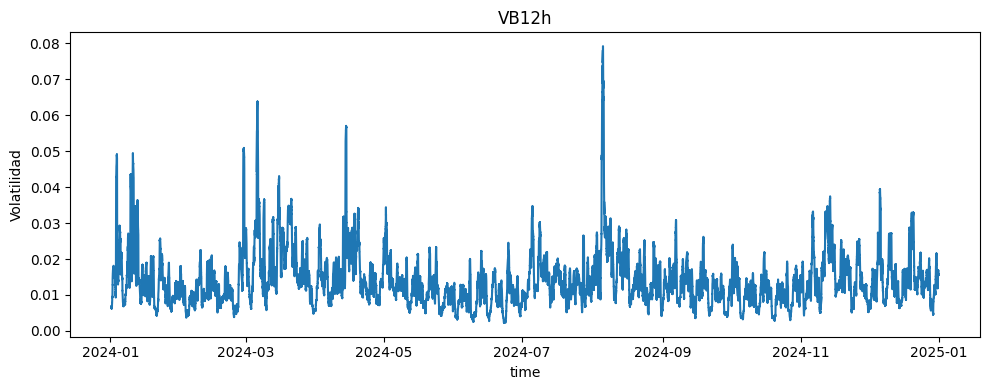

In [ ]:
s = vp_btc["VB12h"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(vp_btc.loc[s.index, "time"], s.values)
plt.title("VB12h")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

In [ ]:
# As we can see on the mutual information test and the theory of hf data, 5 seg use
# to be full of noise wich makes it so hard to understan and predict. Never the less, is
# good to say that above the mi results are ver bad vb5s has more mi with low frequencys:
# Variable  Mutual Information
# 4     VB3m            0.000002
# 0     VB1w            0.000002
# 1     VB2w            0.000002
# 3     VB2m            0.000001
# 2     VB1m            0.000001

# In hf, has its maximun value at 2 minutes
#   Variable  Mutual Information
# 0     VB2m        1.676028e-06
# 1     VB5m        1.739278e-07
# 2    VB10m        1.106815e-07

## 15 mins

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB1w","VB2w","VB1m","VB2m","VB3m"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15m'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15m'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
4     VB3m            0.000002
1     VB2w            0.000002
3     VB2m            0.000002
0     VB1w            0.000002
2     VB1m            0.000001


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB1d","VB2d","VB3d","VB5d"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15m'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15m'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
3     VB5d            0.000001
2     VB3d            0.000001
0     VB1d            0.000001
1     VB2d            0.000001


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB6h","VB8h","VB12h"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15m'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15m'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
2    VB12h        6.641046e-07
1     VB8h        3.320520e-07
0     VB6h        3.004279e-07


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB1h","VB2h","VB3h"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15m'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15m'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
0     VB1h        2.371724e-07
2     VB3h        1.581144e-07
1     VB2h        1.423029e-07


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB20m","VB30m","VB45m"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
1    VB30m        3.162320e-07
2    VB45m        2.055510e-07
0    VB20m        1.739278e-07


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB2m","VB5m","VB10m"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
0     VB2m        1.676028e-06
1     VB5m        1.739278e-07
2    VB10m        1.106815e-07


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB45s","VB1m","VB90s"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
1     VB1m        1.391418e-06
0    VB45s        6.324494e-08
2    VB90s        4.743335e-08


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB10s","VB15s", "VB30s"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
1    VB15s        7.905652e-08
0    VB10s        3.162177e-08
2    VB30s        1.581019e-08


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Lista de variables
variables = ["VB30s"]

# Filtrar filas donde B1 no sea NaN
df_filtrado = vp_btc[~vp_btc['VB15s'].isna()]

# Definir X e y
X = df_filtrado[variables].fillna(0)  # Podés seguir llenando NaN en X si querés
y = df_filtrado['VB15s'].astype(int)     # Ya no tiene NaN, se puede convertir directamente


# Cálculo de información mutua
mi = mutual_info_classif(X, y)

# Mostrar resultados como DataFrame ordenado
mi_df = pd.DataFrame({'Variable': variables, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df)

  Variable  Mutual Information
0    VB30s        6.324494e-08


ANALISIS VISUAL

Bloque elegido:
Inicio: 2024-12-28 00:54:21
Fin   : 2024-12-28 00:59:21


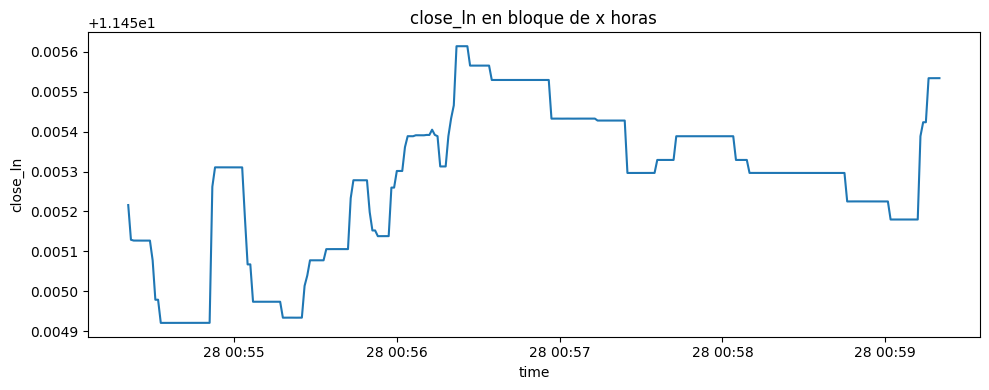

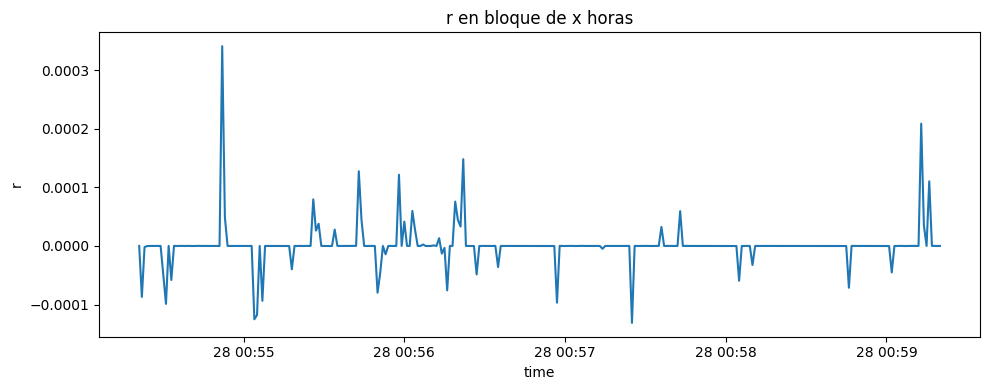

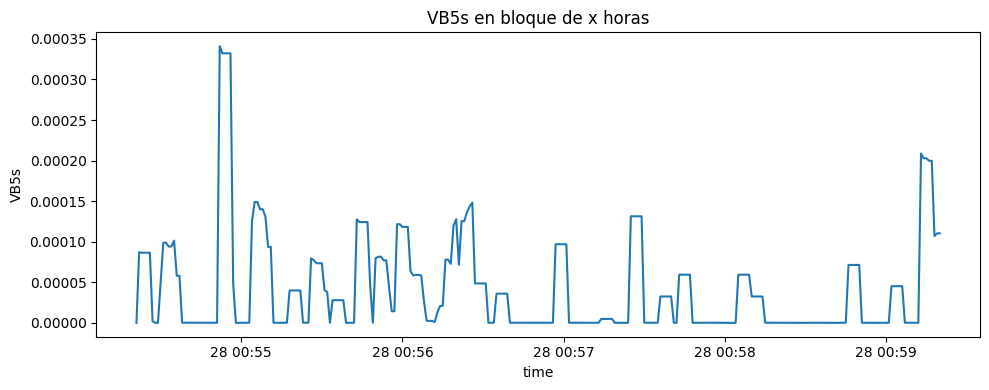

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
vp_btc["time"] = pd.to_datetime(vp_btc["time"])

# 1) Definir rango posible para elegir un bloque continuo de 8 horas
t_min = vp_btc["time"].min()
t_max = vp_btc["time"].max() - pd.Timedelta(hours=8)

# Elegir aleatoriamente un inicio dentro del rango
total_segundos = int((t_max - t_min).total_seconds())
offset_segundos = np.random.randint(0, total_segundos + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar solo las filas dentro de esas 8 horas continuas
mask = (vp_btc["time"] >= t_inicio) & (vp_btc["time"] < t_fin)
sub = vp_btc.loc[mask, ["time", "close_ln", "r", "VB5s"]].dropna()

# 3) Graficar las tres series en bloques separados

# 1) hs aleatorias y close_ln
plt.figure(figsize=(10, 4))
plt.plot(sub["time"], sub["close_ln"])
plt.title("close_ln en bloque de x horas")
plt.xlabel("time"); plt.ylabel("close_ln")
plt.tight_layout(); plt.show()

# 2) hs aleatorias y r
plt.figure(figsize=(10, 4))
plt.plot(sub["time"], sub["r"])
plt.title("r en bloque de x horas")
plt.xlabel("time"); plt.ylabel("r")
plt.tight_layout(); plt.show()

# 3) hs aleatorias y VB5s
plt.figure(figsize=(10, 4))
plt.plot(sub["time"], sub["VB5s"])
plt.title("VB5s en bloque de x horas")
plt.xlabel("time"); plt.ylabel("VB5s")
plt.tight_layout(); plt.show()

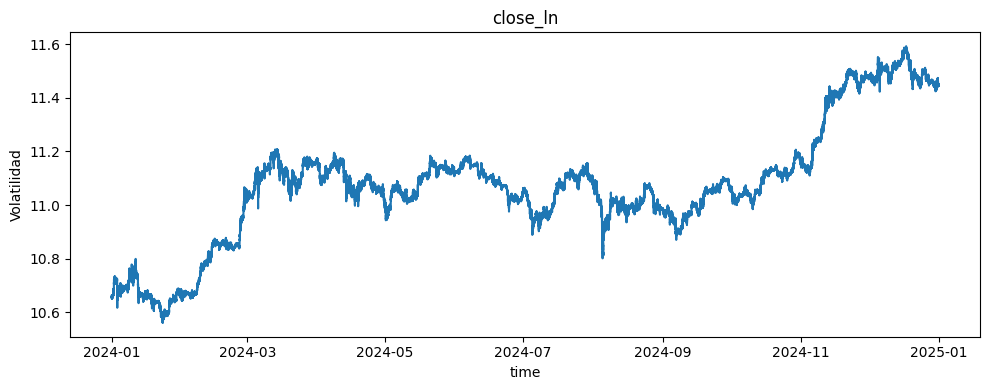

In [ ]:
s = vp_btc["close_ln"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(vp_btc.loc[s.index, "time"], s.values)
plt.title("close_ln")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

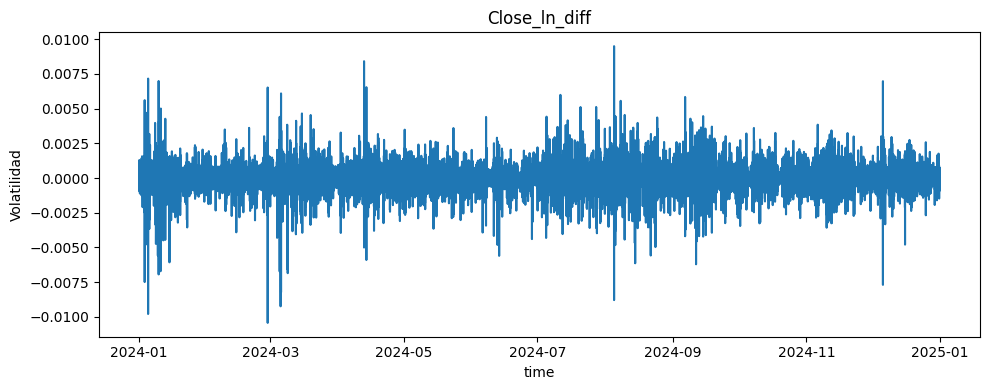

In [ ]:
s = vp_btc["r"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(vp_btc.loc[s.index, "time"], s.values)
plt.title("Close_ln_diff")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

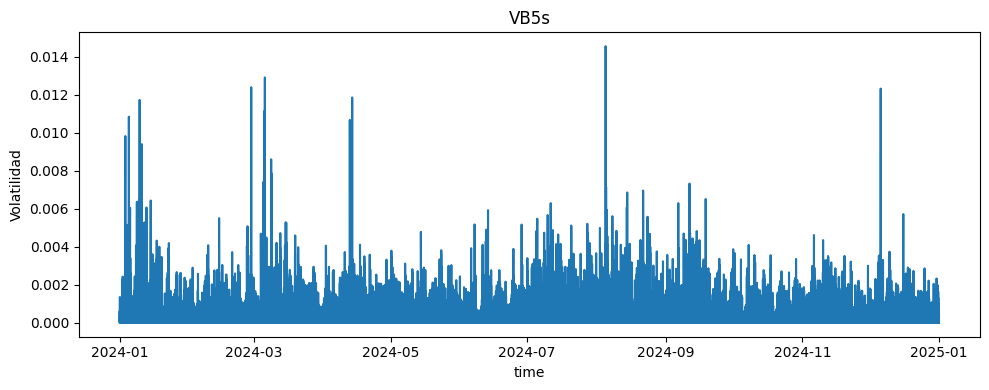

In [ ]:
s = vp_btc["VB5s"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(vp_btc.loc[s.index, "time"], s.values)
plt.title("VB5s")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

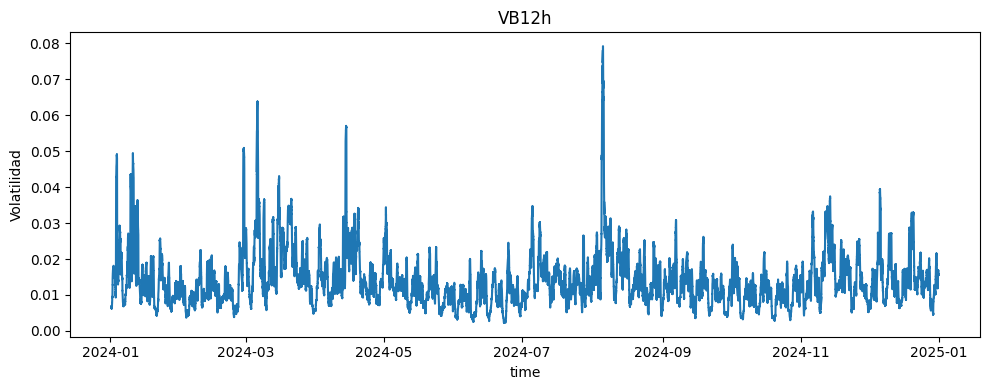

In [ ]:
s = vp_btc["VB12h"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(vp_btc.loc[s.index, "time"], s.values)
plt.title("VB12h")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

In [ ]:
# As we can see on the mutual information test and the theory of hf data, 5 seg use
# to be full of noise wich makes it so hard to understan and predict. Never the less, is
# good to say that above the mi results are ver bad vb5s has more mi with low frequencys:
# Variable  Mutual Information
# 4     VB3m            0.000002
# 0     VB1w            0.000002
# 1     VB2w            0.000002
# 3     VB2m            0.000001
# 2     VB1m            0.000001

# In hf, has its maximun value at 2 minutes
#   Variable  Mutual Information
# 0     VB2m        1.676028e-06
# 1     VB5m        1.739278e-07
# 2    VB10m        1.106815e-07

##**hrs**

5 seconds

In [ ]:
import numpy as np

# Copia mínima con solo lo necesario
tmp = vp_btc[["time", "VB5s"]].dropna().copy()

# Extraer la hora del día (0–23)
tmp["hour"] = tmp["time"].dt.hour

# Función de moda (primer valor si hay varias)
def _mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

# Agrupar por hora y calcular estadísticos
stats_vb5s = tmp.groupby("hour")["VB5s"].agg(
    media="mean",
    moda=_mode,
    mediana="median",
    p10=lambda x: x.quantile(0.10),
    p30=lambda x: x.quantile(0.30),
    p70=lambda x: x.quantile(0.70),
    p90=lambda x: x.quantile(0.90),
    p95=lambda x: x.quantile(0.95),
    p99=lambda x: x.quantile(0.99),
)

s = vp_btc["VB5s"].dropna()

print("Media:", s.mean())
print("Moda:", s.mode().iloc[0] if not s.mode().empty else np.nan)
print("Mediana:", s.median())
print("P10:", s.quantile(0.10))
print("P30:", s.quantile(0.30))
print("P70:", s.quantile(0.70))
print("P90:", s.quantile(0.90))
print("P95:", s.quantile(0.95))
print("P99:", s.quantile(0.99))
print(stats_vb5s)

Media: 8.857501286165822e-05
Moda: 0.0
Mediana: 3.564684841039498e-05
P10: 1.6417464587574001e-07
P30: 2.9412437093690114e-07
P70: 0.0001079456444296502
P90: 0.00023884917958195726
P95: 0.00033341342135634306
P99: 0.0006163416821161551
         media  moda       mediana           p10           p30       p70  \
hour                                                                       
0     0.000087   0.0  4.252014e-05  1.662341e-07  3.050002e-07  0.000109   
1     0.000088   0.0  4.345564e-05  1.649012e-07  3.059172e-07  0.000110   
2     0.000077   0.0  2.565902e-05  1.604382e-07  2.785364e-07  0.000094   
3     0.000067   0.0  1.898752e-06  1.560655e-07  2.645324e-07  0.000080   
4     0.000058   0.0  3.983810e-07  1.546702e-07  2.578066e-07  0.000067   
5     0.000056   0.0  3.827940e-07  1.543200e-07  2.553057e-07  0.000063   
6     0.000058   0.0  4.293953e-07  1.557138e-07  2.598511e-07  0.000066   
7     0.000064   0.0  3.639664e-06  1.592667e-07  2.716871e-07  0.000076   
8   

30 seconds

In [ ]:
import numpy as np

# Copia mínima con solo lo necesario
tmp = vp_btc[["time", "VB30s"]].dropna().copy()

# Extraer la hora del día (0–23)
tmp["hour"] = tmp["time"].dt.hour

# Función de moda (primer valor si hay varias)
def _mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

# Agrupar por hora y calcular estadísticos
stats_VB30s = tmp.groupby("hour")["VB30s"].agg(
    media="mean",
    moda=_mode,
    mediana="median",
    p10=lambda x: x.quantile(0.10),
    p30=lambda x: x.quantile(0.30),
    p70=lambda x: x.quantile(0.70),
    p90=lambda x: x.quantile(0.90),
    p95=lambda x: x.quantile(0.95),
    p99=lambda x: x.quantile(0.99),
)

s = vp_btc["VB30s"].dropna()

print("Media:", s.mean())
print("Moda:", s.mode().iloc[0] if not s.mode().empty else np.nan)
print("Mediana:", s.median())
print("P10:", s.quantile(0.10))
print("P30:", s.quantile(0.30))
print("P70:", s.quantile(0.70))
print("P90:", s.quantile(0.90))
print("P95:", s.quantile(0.95))
print("P99:", s.quantile(0.99))
print(stats_VB30s)

Media: 0.0002923038505850245
Moda: 0.0
Mediana: 0.0002197304978389798
P10: 6.907884814893391e-06
P30: 0.00013000729208512016
P70: 0.00034076980686546023
P90: 0.0006152991999340779
P95: 0.0008106569838796513
P99: 0.0014124583166203598
         media          moda   mediana           p10       p30       p70  \
hour                                                                       
0     0.000290  5.772828e-07  0.000233  3.758735e-05  0.000147  0.000342   
1     0.000293  5.685119e-07  0.000232  4.074498e-05  0.000148  0.000340   
2     0.000262  5.341155e-07  0.000204  5.962901e-06  0.000125  0.000303   
3     0.000232  4.951782e-07  0.000178  7.290196e-07  0.000104  0.000270   
4     0.000207  5.911365e-07  0.000158  6.227691e-07  0.000087  0.000246   
5     0.000200  0.000000e+00  0.000152  6.196164e-07  0.000084  0.000236   
6     0.000206  5.858122e-07  0.000159  6.554210e-07  0.000090  0.000241   
7     0.000225  4.992085e-07  0.000173  7.933665e-07  0.000101  0.000262   
8     

90 seconds

In [ ]:
import numpy as np

# Copia mínima con solo lo necesario
tmp = vp_btc[["time", "VB90s"]].dropna().copy()

# Extraer la hora del día (0–23)
tmp["hour"] = tmp["time"].dt.hour

# Función de moda (primer valor si hay varias)
def _mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

# Agrupar por hora y calcular estadísticos
stats_VB90s = tmp.groupby("hour")["VB90s"].agg(
    media="mean",
    moda=_mode,
    mediana="median",
    p10=lambda x: x.quantile(0.10),
    p30=lambda x: x.quantile(0.30),
    p70=lambda x: x.quantile(0.70),
    p90=lambda x: x.quantile(0.90),
    p95=lambda x: x.quantile(0.95),
    p99=lambda x: x.quantile(0.99),
)

s = vp_btc["VB90s"].dropna()

print("Media:", s.mean())
print("Moda:", s.mode().iloc[0] if not s.mode().empty else np.nan)
print("Mediana:", s.median())
print("P10:", s.quantile(0.10))
print("P30:", s.quantile(0.30))
print("P70:", s.quantile(0.70))
print("P90:", s.quantile(0.90))
print("P95:", s.quantile(0.95))
print("P99:", s.quantile(0.99))
print(stats_VB90s)

Media: 0.0005464884791673085
Moda: 8.83499388447246e-07
Mediana: 0.0004209621740211523
P10: 0.00014202880188820893
P30: 0.0002839160285857633
P70: 0.000614352209576274
P90: 0.0010707374502353054
P95: 0.0013971723807753567
P99: 0.0023929911013690756
         media          moda   mediana       p10       p30       p70  \
hour                                                                   
0     0.000543  8.472372e-07  0.000444  0.000173  0.000318  0.000611   
1     0.000548  8.478223e-07  0.000440  0.000176  0.000316  0.000609   
2     0.000495  1.406197e-06  0.000394  0.000145  0.000278  0.000548   
3     0.000442  8.712194e-07  0.000350  0.000123  0.000241  0.000491   
4     0.000398  9.628982e-07  0.000316  0.000105  0.000215  0.000447   
5     0.000386  9.627896e-07  0.000304  0.000103  0.000210  0.000428   
6     0.000396  8.834994e-07  0.000316  0.000109  0.000221  0.000437   
7     0.000428  8.548845e-07  0.000341  0.000119  0.000238  0.000474   
8     0.000456  9.627833e-07  0

2 minutes

In [ ]:
import numpy as np

# Copia mínima con solo lo necesario
tmp = vp_btc[["time", "VB2m"]].dropna().copy()

# Extraer la hora del día (0–23)
tmp["hour"] = tmp["time"].dt.hour

# Función de moda (primer valor si hay varias)
def _mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

# Agrupar por hora y calcular estadísticos
stats_VB2m = tmp.groupby("hour")["VB2m"].agg(
    media="mean",
    moda=_mode,
    mediana="median",
    p10=lambda x: x.quantile(0.10),
    p30=lambda x: x.quantile(0.30),
    p70=lambda x: x.quantile(0.70),
    p90=lambda x: x.quantile(0.90),
    p95=lambda x: x.quantile(0.95),
    p99=lambda x: x.quantile(0.99),
)

s = vp_btc["VB2m"].dropna()

print("Media:", s.mean())
print("Moda:", s.mode().iloc[0] if not s.mode().empty else np.nan)
print("Mediana:", s.median())
print("P10:", s.quantile(0.10))
print("P30:", s.quantile(0.30))
print("P70:", s.quantile(0.70))
print("P90:", s.quantile(0.90))
print("P95:", s.quantile(0.95))
print("P99:", s.quantile(0.99))
print(stats_VB2m)

Media: 0.0006392601939518959
Moda: 1.0830553972442648e-06
Mediana: 0.0004939723728289014
P10: 0.00018074463610099646
P30: 0.00033922949318584365
P70: 0.0007142297612214956
P90: 0.0012383273733334375
P95: 0.001613624736206378
P99: 0.002756320732435834
         media          moda   mediana       p10       p30       p70  \
hour                                                                   
0     0.000635  9.840914e-07  0.000520  0.000216  0.000381  0.000709   
1     0.000641  1.007130e-06  0.000517  0.000220  0.000377  0.000706   
2     0.000579  1.120361e-06  0.000464  0.000184  0.000332  0.000638   
3     0.000518  1.400223e-06  0.000414  0.000160  0.000291  0.000570   
4     0.000467  1.124815e-06  0.000372  0.000141  0.000260  0.000519   
5     0.000453  1.102848e-06  0.000359  0.000138  0.000254  0.000497   
6     0.000464  1.156762e-06  0.000373  0.000145  0.000268  0.000506   
7     0.000501  1.023353e-06  0.000401  0.000156  0.000288  0.000551   
8     0.000535  1.125578e-06 

5 minutes

In [ ]:
import numpy as np

# Copia mínima con solo lo necesario
tmp = vp_btc[["time", "VB5m"]].dropna().copy()

# Extraer la hora del día (0–23)
tmp["hour"] = tmp["time"].dt.hour

# Función de moda (primer valor si hay varias)
def _mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

# Agrupar por hora y calcular estadísticos
stats_VB5m = tmp.groupby("hour")["VB5m"].agg(
    media="mean",
    moda=_mode,
    mediana="median",
    p10=lambda x: x.quantile(0.10),
    p30=lambda x: x.quantile(0.30),
    p70=lambda x: x.quantile(0.70),
    p90=lambda x: x.quantile(0.90),
    p95=lambda x: x.quantile(0.95),
    p99=lambda x: x.quantile(0.99),
)

s = vp_btc["VB5m"].dropna()

print("Media:", s.mean())
print("Moda:", s.mode().iloc[0] if not s.mode().empty else np.nan)
print("Mediana:", s.median())
print("P10:", s.quantile(0.10))
print("P30:", s.quantile(0.30))
print("P70:", s.quantile(0.70))
print("P90:", s.quantile(0.90))
print("P95:", s.quantile(0.95))
print("P99:", s.quantile(0.99))
print(stats_VB5m)

Media: 0.0010424414039616413
Moda: 1.7349126546754218e-06
Mediana: 0.0008127636712478106
P10: 0.00034576407291800446
P30: 0.0005792498116893276
P70: 0.0011511612515786316
P90: 0.0019713856376366444
P95: 0.0025428306475437407
P99: 0.004271743005396846
         media      moda   mediana       p10       p30       p70       p90  \
hour                                                                         
0     0.001032  0.000002  0.000854  0.000406  0.000647  0.001131  0.001851   
1     0.001044  0.000002  0.000849  0.000409  0.000639  0.001137  0.001816   
2     0.000948  0.000225  0.000773  0.000356  0.000570  0.001030  0.001668   
3     0.000851  0.000002  0.000687  0.000314  0.000503  0.000923  0.001469   
4     0.000767  0.000002  0.000616  0.000284  0.000456  0.000833  0.001369   
5     0.000747  0.000002  0.000600  0.000279  0.000446  0.000801  0.001299   
6     0.000761  0.000002  0.000616  0.000293  0.000468  0.000814  0.001311   
7     0.000820  0.000002  0.000665  0.000308  0

10 minutes

In [ ]:
import numpy as np

# Copia mínima con solo lo necesario
tmp = vp_btc[["time", "VB10m"]].dropna().copy()

# Extraer la hora del día (0–23)
tmp["hour"] = tmp["time"].dt.hour

# Función de moda (primer valor si hay varias)
def _mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

# Agrupar por hora y calcular estadísticos
stats_VB10m = tmp.groupby("hour")["VB10m"].agg(
    media="mean",
    moda=_mode,
    mediana="median",
    p10=lambda x: x.quantile(0.10),
    p30=lambda x: x.quantile(0.30),
    p70=lambda x: x.quantile(0.70),
    p90=lambda x: x.quantile(0.90),
    p95=lambda x: x.quantile(0.95),
    p99=lambda x: x.quantile(0.99),
)

s = vp_btc["VB10m"].dropna()

print("Media:", s.mean())
print("Moda:", s.mode().iloc[0] if not s.mode().empty else np.nan)
print("Mediana:", s.median())
print("P10:", s.quantile(0.10))
print("P30:", s.quantile(0.30))
print("P70:", s.quantile(0.70))
print("P90:", s.quantile(0.90))
print("P95:", s.quantile(0.95))
print("P99:", s.quantile(0.99))
print(stats_VB10m)

Media: 0.0015004558003062173
Moda: 2.4222916691009873e-06
Mediana: 0.0011785197473769293
P10: 0.0005315620090086854
P30: 0.0008528388956533129
P70: 0.0016546145150558769
P90: 0.0028017051578253477
P95: 0.003601494615908417
P99: 0.005937083511005204
         media      moda   mediana       p10       p30       p70       p90  \
hour                                                                         
0     0.001477  0.000336  0.001227  0.000619  0.000953  0.001606  0.002647   
1     0.001503  0.000798  0.001227  0.000609  0.000945  0.001632  0.002585   
2     0.001369  0.000317  0.001120  0.000550  0.000847  0.001474  0.002361   
3     0.001234  0.000233  0.001001  0.000489  0.000751  0.001327  0.002100   
4     0.001106  0.000142  0.000891  0.000443  0.000674  0.001199  0.001947   
5     0.001080  0.000651  0.000877  0.000440  0.000660  0.001155  0.001858   
6     0.001094  0.000002  0.000893  0.000464  0.000696  0.001158  0.001830   
7     0.001179  0.000002  0.000964  0.000481  0.0

In [ ]:
vp_btc.tail(10)

,time,day,close,close_ln,SD_5,VB5s,SD_10,VB10s,SD_15,VB15s,...,SD_28800,VB8h,SD_43200,VB12h,SD_60,VB1m,SD_90,VB90s,VB2m,VB5m
31622390,2024-12-31 23:59:50,2,93576.00,11.446529,0.000002,0.000004,0.0,0.0,0.000003,0.000011,...,0.005362,0.909904,0.008212,1.706873,0.000151,0.001170,0.000166,0.001576,0.009474,0.009474
31622391,2024-12-31 23:59:51,2,93576.00,11.446529,0.000000,0.000000,0.0,0.0,0.000003,0.000011,...,0.005361,0.909806,0.008212,1.706898,0.000150,0.001161,0.000168,0.001591,0.009434,0.009434
31622392,2024-12-31 23:59:52,2,93576.00,11.446529,0.000000,0.000000,0.0,0.0,0.000003,0.000011,...,0.005361,0.909707,0.008212,1.706923,0.000151,0.001170,0.000169,0.001605,0.009394,0.009394
31622393,2024-12-31 23:59:53,2,93576.01,11.446529,0.000002,0.000004,0.0,0.0,0.000003,0.000011,...,0.005360,0.909610,0.008213,1.706947,0.000152,0.001177,0.000170,0.001617,0.009353,0.009353
31622394,2024-12-31 23:59:54,2,93576.00,11.446529,0.000002,0.000004,0.0,0.0,0.000003,0.000011,...,0.005359,0.909513,0.008213,1.706972,0.000153,0.001183,0.000172,0.001627,0.009313,0.009313
31622395,2024-12-31 23:59:55,2,93576.01,11.446529,0.000002,0.000004,0.0,0.0,0.000003,0.000011,...,0.005359,0.909416,0.008213,1.706996,0.000154,0.001192,0.000173,0.001637,0.009274,0.009274
31622396,2024-12-31 23:59:56,2,93576.01,11.446529,0.000002,0.000004,0.0,0.0,0.000003,0.000011,...,0.005358,0.909317,0.008213,1.707021,0.000155,0.001199,0.000173,0.001645,0.009235,0.009235
31622397,2024-12-31 23:59:57,2,93576.01,11.446529,0.000002,0.000004,0.0,0.0,0.000003,0.000011,...,0.005358,0.909217,0.008213,1.707045,0.000156,0.001206,0.000174,0.001652,0.009200,0.009200
31622398,2024-12-31 23:59:58,2,93576.01,11.446529,0.000002,0.000004,0.0,0.0,0.000003,0.000011,...,0.005357,0.909117,0.008213,1.707070,0.000156,0.001212,0.000175,0.001657,0.009164,0.009164
31622399,2024-12-31 23:59:59,2,93576.00,11.446529,0.000002,0.000004,0.0,0.0,0.000003,0.000011,...,0.005356,0.909017,0.008213,1.707094,0.000157,0.001217,0.000175,0.001661,0.009134,0.009134


In [ ]:
# Una vez analizada la varianza y estabilidad de RV en diferentes intervalor de tiempo
# se observa que para magnitudes muy pequeñas la dispersion y el skw es muy alto, asi
# como la diferencia entre media y mediana. Esta relacion se hacer relativamente estable
# a partir de sd a 90 segundos (todo calculado sobre r, obvio), entonces se tomara esta
# como el tamaño de rolling window, y se intentara predecir a 15 minutos, estas seran las opciones:

# 1. rw = 90 seg y lote = 15 minutos
# 2. rw = 2 minutos y lote = 10 minutos

# Wavelets VB parametric


## vol y vol truncada

In [ ]:
vp_btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31622400 entries, 0 to 31622399
Data columns (total 45 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   SD_5      float64       
 6   VB5s      float64       
 7   SD_10     float64       
 8   VB10s     float64       
 9   SD_15     float64       
 10  VB15s     float64       
 11  SD_20     float64       
 12  VB20s     float64       
 13  SD_30     float64       
 14  VB30s     float64       
 15  SD_45     float64       
 16  VB45s     float64       
 17  SD_60     float64       
 18  VB1m      float64       
 19  SD_90     float64       
 20  VB90s     float64       
 21  SD_120    float64       
 22  VB2m      float64       
 23  SD_300    float64       
 24  VB5m      float64       
 25  SD_600    float64       
 26  VB10m     float64       
 27  SD_1200   

In [ ]:
btc = vp_btc.iloc[:, [0, 1, 2, 3, 4, 20]]
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31622400 entries, 0 to 31622399
Data columns (total 6 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   VB90s     float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 1.4 GB


In [ ]:
import numpy as np

med_vb = btc["VB90s"].median()
thr_vb = 3 * med_vb

x = btc["VB90s"].to_numpy()
btc["VB90s_trunc"] = np.sign(x) * np.minimum(np.abs(x), thr_vb)

/tmp/ipython-input-2555272337.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc["VB90s_trunc"] = np.sign(x) * np.minimum(np.abs(x), thr_vb)


/tmp/ipython-input-309568548.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc["time"] = pd.to_datetime(btc["time"])


Bloque elegido:
Inicio: 2024-07-18 06:29:53
Fin   : 2024-07-18 14:29:53


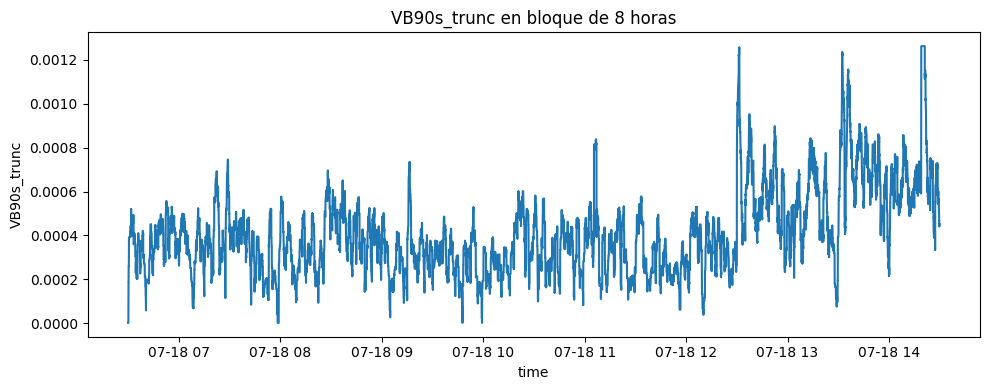

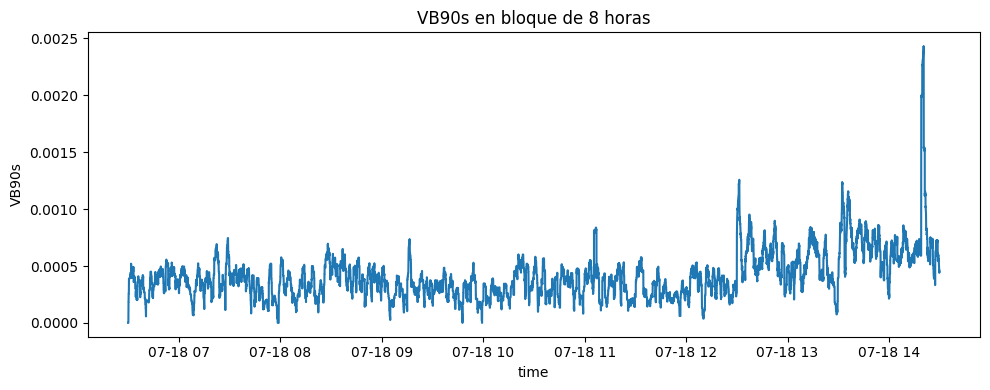

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
btc["time"] = pd.to_datetime(btc["time"])

# 1) Definir rango posible para elegir un bloque continuo de 8 horas
t_min = btc["time"].min()
t_max = btc["time"].max() - pd.Timedelta(hours=8)

# Elegir aleatoriamente un inicio dentro del rango
total_segundos = int((t_max - t_min).total_seconds())
offset_segundos = np.random.randint(0, total_segundos + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(hours=8)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar solo las filas dentro de esas 8 horas continuas
mask = (btc["time"] >= t_inicio) & (btc["time"] < t_fin)
sub = btc.loc[mask, ["time", "VB90s_trunc", "VB90s"]].dropna()

# 3) Graficar las tres series en bloques separados

# 1) hs aleatorias y VB90s_trunc
plt.figure(figsize=(10, 4))
plt.plot(sub["time"], sub["VB90s_trunc"])
plt.title("VB90s_trunc en bloque de 8 horas")
plt.xlabel("time"); plt.ylabel("VB90s_trunc")
plt.tight_layout(); plt.show()

# 2) hs aleatorias y r
plt.figure(figsize=(10, 4))
plt.plot(sub["time"], sub["VB90s"])
plt.title("VB90s en bloque de 8 horas")
plt.xlabel("time"); plt.ylabel("VB90s")
plt.tight_layout(); plt.show()

In [ ]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31622400 entries, 0 to 31622399
Data columns (total 7 columns):
 #   Column       Dtype         
---  ------       -----         
 0   time         datetime64[ns]
 1   day          int64         
 2   close        float64       
 3   close_ln     float64       
 4   r            float64       
 5   VB90s        float64       
 6   VB90s_trunc  float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 1.6 GB


## Vol parametrica

Truncada

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = btc["VB90s_trunc"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 12)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    details = coeffs[1:]           # [D_J, D_{J-1}, ..., D_1]
    total_energy = np.sum(x**2)
    wave_energy = sum(np.sum(d**2) for d in details)
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    d1 = details[-1]               # detalle más fino (nivel 1)
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    energy_by_level = [np.sum(d**2) for d in details]  # orden: [J,...,1]

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level
    })


In [ ]:
res_df = pd.DataFrame(results)

# ranking simple: cerca de energía 1 y bajo max_acf_level1
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)
res_df = res_df.sort_values(
    by=["energy_deviation", "max_acf_level1"],
    ascending=[True, True]
).reset_index(drop=True)

print(res_df[["wavelet", "J", "energy_ratio", "energy_deviation",
              "max_acf_level1", "mean_abs_acf_level1"]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

  wavelet   J  energy_ratio  energy_deviation  max_acf_level1  \
0     db6  12      0.097140          0.902860        0.178562   
1    sym4  12      0.097011          0.902989        0.186329   
2     db4  12      0.096978          0.903022        0.184710   
3    sym6  12      0.096773          0.903227        0.179195   

   mean_abs_acf_level1  
0             0.013423  
1             0.012412  
2             0.012313  
3             0.013485  

Wavelet sugerida: db6 con J = 12


Pura

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = btc["VB90s"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 12)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    details = coeffs[1:]           # [D_J, D_{J-1}, ..., D_1]
    total_energy = np.sum(x**2)
    wave_energy = sum(np.sum(d**2) for d in details)
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    d1 = details[-1]               # detalle más fino (nivel 1)
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    energy_by_level = [np.sum(d**2) for d in details]  # orden: [J,...,1]

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level
    })


In [ ]:
res_df = pd.DataFrame(results)

# ranking simple: cerca de energía 1 y bajo max_acf_level1
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)
res_df = res_df.sort_values(
    by=["energy_deviation", "max_acf_level1"],
    ascending=[True, True]
).reset_index(drop=True)

print(res_df[["wavelet", "J", "energy_ratio", "energy_deviation",
              "max_acf_level1", "mean_abs_acf_level1"]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

  wavelet   J  energy_ratio  energy_deviation  max_acf_level1  \
0    sym4  12      0.178101          0.821899        0.182642   
1     db4  12      0.177806          0.822194        0.193267   
2    sym6  12      0.177369          0.822631        0.175555   
3     db6  12      0.176197          0.823803        0.178425   

   mean_abs_acf_level1  
0             0.012230  
1             0.013004  
2             0.013216  
3             0.013625  

Wavelet sugerida: sym4 con J = 12


In [ ]:
# As is reasonable, the volatility of a cryptocurrency is not directly analyzed using a non-parametric estimator.
# At least, not in its usual methods, due to the non-oscillatory nature of the
# phenomenon. Therefore, it could be analyzed by its variations, but for
# practicality, we proceed to derive it directly using a non-parametric estimator.

#Wlts VB non parametric

## r

In [ ]:
btc = vp_btc.iloc[:, [0, 1, 2, 3, 4, 20]]
btc["r"] = btc["close_ln"].diff()
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31622400 entries, 0 to 31622399
Data columns (total 6 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   VB90s     float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 1.4 GB


/tmp/ipython-input-708902729.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc["r"] = btc["close_ln"].diff()


Media: 2.5120646581128606e-08
Mediana: 0.0
Moda: 0.0
Desvío estándar: 7.889523548583307e-05
Skew: -0.5114786310036552
Deciles:
d1 : -3.197902176488299e-05
d2 : -1.5868246627803728e-07
d3 : 0.0
d4 : 0.0
d5 : 0.0
d6 : 0.0
d7 : 0.0
d8 : 1.5887202131636968e-07
d9 : 3.2977318405968956e-05
Percentiles mas altos:
d95 : 9.834005317372879e-05
d96 : 0.00011777788311974269
d97 : 0.00014190530077364365
d98 : 0.00017744033164035497
d99 : 0.0002440167988989827
d100 : 0.009499406860793869
Permiles
p970 : 0.00014190530077364365
p971 : 0.0001448376012881596
p972 : 0.0001479439217675349
p973 : 0.0001508185198520593
p974 : 0.00015421826780747145
p975 : 0.00015756713446064553
p976 : 0.00016115308126894945
p977 : 0.00016494367603301898
p978 : 0.0001690070533779602
p979 : 0.0001731874776346167
p980 : 0.00017744033164035497
p981 : 0.00018199130669448852
p982 : 0.00018701306985351325
p983 : 0.00019256156359617199
p984 : 0.00019843568757865382
p985 : 0.0002034958796500599
p986 : 0.0002102443719062705
p987 : 0.

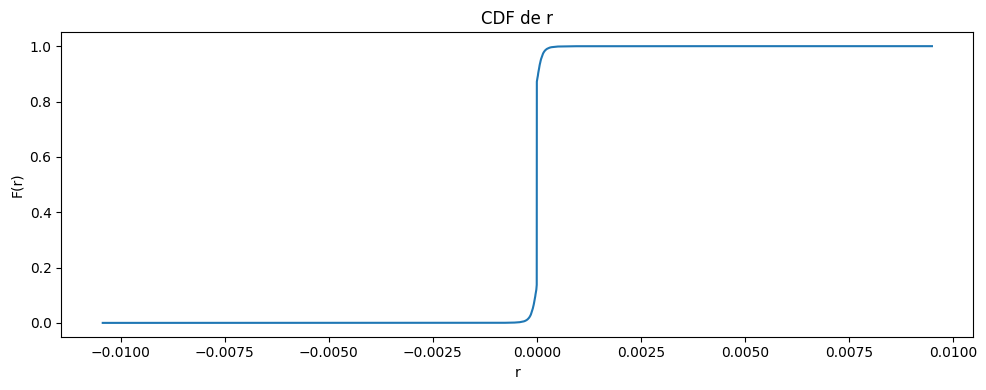

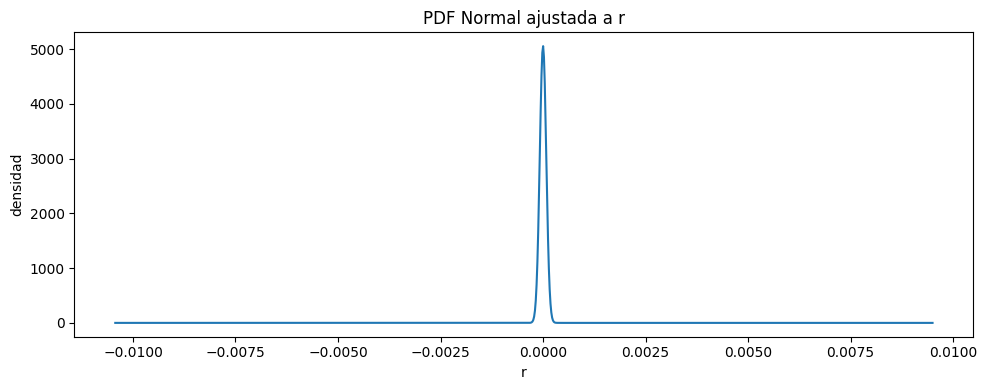

/tmp/ipython-input-3700812858.py:91: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


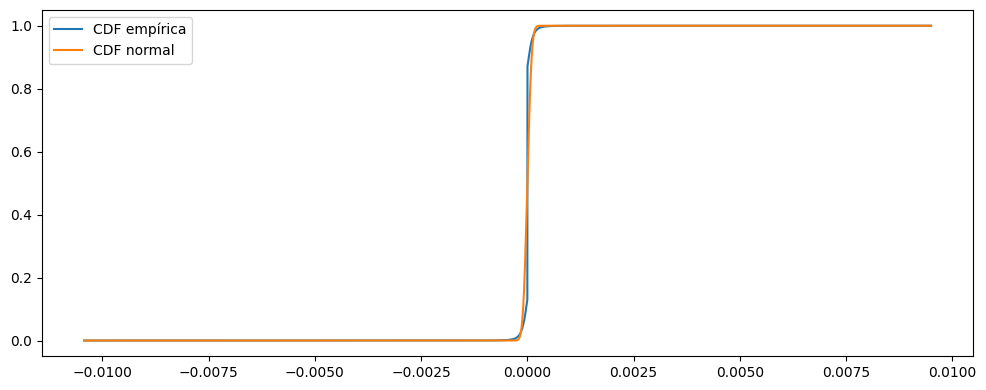

In [ ]:
import numpy as np
from scipy.stats import skew

s = btc["r"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)

# 10 deciles (0.1, 0.2, ..., 0.9)
deciles = {f"d{int(p*10)}": s.quantile(p) for p in np.arange(0.1, 1.0, 0.1)}

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)
print("Deciles:")
for k, v in deciles.items():
    print(k, ":", v)

# TOP Percentiles, permiles, permisiles y fractiles
Percentiles = {f"d{int(p*100)}": s.quantile(p) for p in np.arange(0.95, 1.0, 0.01)}
print("Percentiles mas altos:")
for k, v in Percentiles.items():
    print(k, ":", v)
permiles = {f"p{int(p*1000)}": s.quantile(p)
            for p in np.arange(0.970, 1.001, 0.001)}

print("Permiles")
for k, v in permiles.items():
    print(k, ":", v)

permisiles = {f"p{int(p*10000)}": s.quantile(p)
            for p in np.arange(0.9970, 1.0000, 0.0001)}

print("permisiles")
for k, v in permisiles.items():
    print(k, ":", v)

fractales = {f"p{int(p*100000)}": s.quantile(p)
            for p in np.arange(0.99980, 1.00000, 0.00001)}

print("fractales")
for k, v in fractales.items():
    print(k, ":", v)



import numpy as np
import matplotlib.pyplot as plt

s = btc["r"].dropna().sort_values()

# CDF empírica
y = np.linspace(0, 1, len(s))

plt.figure(figsize=(10,4))
plt.plot(s.values, y)
plt.title("CDF de r")
plt.xlabel("r")
plt.ylabel("F(r)")
plt.tight_layout()
plt.show()


from scipy.stats import skew, norm
import numpy as np
import matplotlib.pyplot as plt

mu, sigma = s.mean(), s.std()
x = np.linspace(s.min(), s.max(), 1000)

pdf = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10,4))
plt.plot(x, pdf)
plt.title("PDF Normal ajustada a r")
plt.xlabel("r")
plt.ylabel("densidad")
plt.tight_layout()
plt.show()

y = np.linspace(0, 1, len(s))
plt.figure(figsize=(10,4))
plt.plot(s.values, y, label="CDF empírica")
plt.plot(x, norm.cdf(x, mu, sigma), label="CDF normal")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# masa central
p0 = (s == 0).mean()
eps = np.nextafter(0, 1)
p0_eps = (np.abs(s) <= eps).mean()
print("P0 (exacto):", p0)
print("P0 (eps):", p0_eps)

deciles = {f"d{int(p*10)}": np.quantile(s, p) for p in np.arange(0.0, 0.5, 0.1)}

for k, v in deciles.items():
    print(k, ":", v)

Percentiles = {f"d{int(p*100)}": np.quantile(s, p) for p in np.arange(0.00, 0.2, 0.001)}
print("Percentiles mas bajos:")
for k, v in Percentiles.items():
    print(k, ":", v)

# permiles = {f"p{int(p*1000)}": np.quantile(s, p)
#             for p in np.arange(0.000, 0.001, 0.0001)}

# print("Permiles")
# for k, v in permiles.items():
#     print(k, ":", v)

# permisiles = {f"p{int(p*10000)}": np.quantile(s, p)
#               for p in np.arange(0.0000, 0.0001, 0.00001)}

# print("permisiles")
# for k, v in permisiles.items():
#     print(k, ":", v)

P0 (exacto): 0.41411260417022755
P0 (eps): 0.41411260417022755
d0 : -0.010431974429630841
d1 : -3.197902176488299e-05
d2 : -1.5868246627803728e-07
d3 : 0.0
d4 : 0.0
Percentiles mas bajos:
d0 : -0.00025664749747932795
d1 : -0.00018285668143556676
d2 : -0.00014508975709263795
d3 : -0.00011970247510232566
d4 : -9.974466886059118e-05
d5 : -8.388683141743768e-05
d6 : -6.867676042770654e-05
d7 : -5.716426673663833e-05
d8 : -4.440811613113738e-05
d9 : -3.285516406397804e-05
d10 : -2.2698309450220208e-05
d11 : -1.1046144127092809e-05
d12 : -1.2950338567954091e-06
d13 : -2.3413906020408595e-07
d14 : -2.1539108814039304e-07
d15 : -1.8422616854252283e-07
d16 : -1.7145013941899379e-07
d17 : -1.6567714666848588e-07
d18 : -1.621919398786531e-07
d19 : -1.5888148752196685e-07


In [ ]:
# cola izquierda quiebre en percentil 12

Regimenes, pdf historica y local

In [ ]:
import numpy as np
import pandas as pd

r = btc["r"].astype(float)

# ---------- 1) Umbrales globales (condicionado a r != 0) ----------
a = r[r.ne(0)].abs().dropna()

q_low  = a.quantile(0.120)   # umbral inferior (activo)
q_high = a.quantile(0.995)   # umbral de extremos

# ---------- 2) Regímenes (3) sobre btc["r"] ----------
R0 = r.eq(0)
R1 = r.ne(0) & r.abs().between(q_low, q_high, inclusive="both")
R2 = r.ne(0) & r.abs().gt(q_high)

btc["regime_g"] = np.select([R0, R1, R2], [0, 1, 2], default=-1).astype("int8")

# ---------- 3) PDF empírica (hist) por régimen ----------
def pdf_hist(x, bins=400, lo=None, hi=None):
    x = x.dropna().to_numpy()
    if x.size == 0:
        return pd.DataFrame({"bin_left": [], "bin_right": [], "pdf": []})
    if lo is None: lo = np.quantile(x, 0.001)
    if hi is None: hi = np.quantile(x, 0.999)
    h, e = np.histogram(x, bins=bins, range=(lo, hi), density=True)
    return pd.DataFrame({"bin_left": e[:-1], "bin_right": e[1:], "pdf": h})

pdf_R0 = pd.DataFrame({"note": ["R0 es un átomo en 0 (masa puntual), no PDF continua."], "P0": [R0.mean()]})
pdf_R1 = pdf_hist(r[R1], bins=400)
pdf_R2 = pdf_hist(r[R2], bins=400)

# ---------- 4) Regímenes locales (ventana móvil) para "PDF histórica vs localizada" ----------
W = 900  # ventana

abs_nz = r.where(r.ne(0)).abs()
q_low_l  = abs_nz.rolling(W, min_periods=max(50, W//10)).quantile(0.120)
q_high_l = abs_nz.rolling(W, min_periods=max(50, W//10)).quantile(0.995)

R0_l = r.eq(0)
R1_l = r.ne(0) & r.abs().ge(q_low_l) & r.abs().le(q_high_l)
R2_l = r.ne(0) & r.abs().gt(q_high_l)

btc["regime_l"] = np.select([R0_l, R1_l, R2_l], [0, 1, 2], default=-1).astype("int8")

# ---------- 5) Features DUMMIES listas para predecir a 15 min ----------
btc["is_R0_g"] = (btc["regime_g"]==0).astype("int8")
btc["is_R1_g"] = (btc["regime_g"]==1).astype("int8")
btc["is_R2_g"] = (btc["regime_g"]==2).astype("int8")

btc["is_R0_l"] = (btc["regime_l"]==0).astype("int8")
btc["is_R1_l"] = (btc["regime_l"]==1).astype("int8")
btc["is_R2_l"] = (btc["regime_l"]==2).astype("int8")

# score de severidad (global/local), 0 fuera de régimen extremo
den_g = (a.quantile(0.995) - a.quantile(0.120))
btc["sev_g"] = np.where(R2, np.log1p((r.abs()-q_high)/den_g), 0.0)

den_l = (q_high_l - q_low_l)
btc["sev_l"] = np.where(R2_l, np.log1p((r.abs()-q_high_l)/den_l.replace(0, np.nan)), 0.0)

# ---------- 6) Objetivo a 15 minutos (900s) desde r1 ----------
# ejemplo: prob de entrar a extremos (R2) en t+900
btc["y_R2_g_t+900"] = (btc["regime_g"].shift(-900)==2).astype("int8")
btc["y_R2_l_t+900"] = (btc["regime_l"].shift(-900)==2).astype("int8")

/tmp/ipython-input-3418716390.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc["regime_g"] = np.select([R0, R1, R2], [0, 1, 2], default=-1).astype("int8")
/tmp/ipython-input-3418716390.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc["regime_l"] = np.select([R0_l, R1_l, R2_l], [0, 1, 2], default=-1).astype("int8")
/tmp/ipython-input-3418716390.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

In [ ]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31622400 entries, 0 to 31622399
Data columns (total 18 columns):
 #   Column        Dtype         
---  ------        -----         
 0   time          datetime64[ns]
 1   day           int64         
 2   close         float64       
 3   close_ln      float64       
 4   r             float64       
 5   VB90s         float64       
 6   regime_g      int8          
 7   regime_l      int8          
 8   is_R0_g       int8          
 9   is_R1_g       int8          
 10  is_R2_g       int8          
 11  is_R0_l       int8          
 12  is_R1_l       int8          
 13  is_R2_l       int8          
 14  sev_g         float64       
 15  sev_l         float64       
 16  y_R2_g_t+900  int8          
 17  y_R2_l_t+900  int8          
dtypes: datetime64[ns](1), float64(6), int64(1), int8(10)
memory usage: 2.2 GB


In [ ]:
btc.tail()

,time,day,close,close_ln,r,VB90s,regime_g,regime_l,is_R0_g,is_R1_g,is_R2_g,is_R0_l,is_R1_l,is_R2_l,sev_g,sev_l,y_R2_g_t+900,y_R2_l_t+900
31622395,2024-12-31 23:59:55,2,93576.01,11.446529,1.068650e-07,0.000289,-1,1,0,0,0,0,1,0,0.0,0.0,0,0
31622396,2024-12-31 23:59:56,2,93576.01,11.446529,0.000000e+00,0.000289,0,0,1,0,0,1,0,0,0.0,0.0,0,0
31622397,2024-12-31 23:59:57,2,93576.01,11.446529,0.000000e+00,0.000289,0,0,1,0,0,1,0,0,0.0,0.0,0,0
31622398,2024-12-31 23:59:58,2,93576.01,11.446529,0.000000e+00,0.000289,0,0,1,0,0,1,0,0,0.0,0.0,0,0
31622399,2024-12-31 23:59:59,2,93576.00,11.446529,-1.068650e-07,0.000289,-1,1,0,0,0,0,1,0,0.0,0.0,0,0


In [ ]:
# regime_g: “dónde cae este retorno respecto a la PDF histórica total”.
# regime_l: “dónde cae este retorno respecto a una PDF local de los últimos 15 min”.
# sev_*: “si es extremo, cuánto de extremo es, con escala y compresión”.

In [ ]:
cols = [
    "regime_g","regime_l",
    "is_R0_g","is_R1_g","is_R2_g",
    "is_R0_l","is_R1_l","is_R2_l",
    "sev_g","sev_l",
    "y_R2_g_t+900","y_R2_l_t+900"
]

btc[cols].describe(include="all")
for c in ["regime_g","regime_l","y_R2_g_t+900","y_R2_l_t+900"]:
    print("\n", c)
    print(btc[c].value_counts(dropna=False).sort_index())


 regime_g
regime_g
-1     2223208
 0    13095234
 1    16211322
 2       92636
Name: count, dtype: int64

 regime_l
regime_l
-1     3068685
 0    13095234
 1    15341889
 2      116592
Name: count, dtype: int64

 y_R2_g_t+900
y_R2_g_t+900
0    31529764
1       92636
Name: count, dtype: int64

 y_R2_l_t+900
y_R2_l_t+900
0    31505809
1      116591
Name: count, dtype: int64


In [ ]:
# regime_g y regime_l — régimen global y local (PDF histórica)

# 0 → r = 0
# 1 → r ≠ 0 y q_0.120 ≤ |r| ≤ q_0.995
# 2 → |r| > q_0.995

# -1 → no clasificado


# y_R2_g_t+ y y_R2_l_t+900 — objetivo a 15 minutos (global)

# y_R2_g/l_t+900 = 1  si regime_g(t+900) == 2
#                0  en caso contrario

wavelets

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = btc["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 12)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet   J  energy_ratio  energy_deviation  max_acf_level1  \
0     db6  12      0.999655          0.000345        0.023256   
1    sym6  12      0.999660          0.000340        0.023488   
2     db4  12      0.999660          0.000340        0.023864   
3    sym4  12      0.999662          0.000338        0.024536   

   mean_abs_acf_level1  entropy_energy          Q_d1  
0             0.002474        1.533197  10340.002499  
1             0.002482        1.533770  10558.300019  
2             0.002733        1.532170  10785.763391  
3             0.002454        1.532621  11089.131847  

Wavelet sugerida: db6 con J = 12

Energía por nivel (J...1) para el mejor wavelet:
[6.50444736e-05 1.35813322e-04 2.86174081e-04 5.59078224e-04
 1.17754654e-03 2.27796699e-03 4.49253424e-03 8.56494858e-03
 1.59252881e-02 2.89015475e-02 4.92443859e-02 8.51341342e-02]
Shares por nivel (J...1):
[3.30570231e-04 6.90232985e-04 1.45439922e-03 2.84135772e-03
 5.98454886e-03 1.15771261e-02 2.28320409e-0

In [ ]:
#todo mal con serie pura y j=12

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = btc["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db6  3      0.829539          0.170461        0.023256   
1    sym6  3      0.828906          0.171094        0.023488   
2     db4  3      0.830189          0.169811        0.023864   
3    sym4  3      0.829203          0.170797        0.024536   

   mean_abs_acf_level1  entropy_energy          Q_d1  
0             0.002474        1.007567  10340.002499  
1             0.002482        1.007115  10558.300019  
2             0.002733        1.007155  10785.763391  
3             0.002454        1.006260  11089.131847  

Wavelet sugerida: db6 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.02890155 0.04924439 0.08513413]
Shares por nivel (J...1):
[0.17700597 0.3015946  0.52139943]


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = btc["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 2)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db6  2      0.682706          0.317294        0.023256   
1    sym6  2      0.682438          0.317562        0.023488   
2     db4  2      0.683555          0.316445        0.023864   
3    sym4  2      0.683186          0.316814        0.024536   

   mean_abs_acf_level1  entropy_energy          Q_d1  
0             0.002474        0.657045  10340.002499  
1             0.002482        0.656822  10558.300019  
2             0.002733        0.656950  10785.763391  
3             0.002454        0.656437  11089.131847  

Wavelet sugerida: db6 con J = 2

Energía por nivel (J...1) para el mejor wavelet:
[0.04924439 0.08513413]
Shares por nivel (J...1):
[0.36646025 0.63353975]


In [ ]:
# j 12: descartado totalmente, ruido infinito
# J 3: mejora en entropia, correlacion muy alto pero un buen Q
# J 2: se cae.

# DB6 es la mejorcita pero sin limpiar no se puede trabajar r. R DEBE SER TRUNCADA

## r_2

In [ ]:
df2 = vp_btc.iloc[:, [0, 1, 2, 3, 4, 20]]
df2 = df2.iloc[::2].copy()
df2["r"] = df2["close_ln"].diff()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15811200 entries, 0 to 31622398
Data columns (total 6 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   VB90s     float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 723.8 MB


Media: 5.024130150986252e-08
Mediana: 0.0
Moda: 0.0
Desvío estándar: 0.00011790179426171092
Skew: -0.4148806636689803
Deciles:
d1 : -8.618286599038072e-05
d2 : -2.3295608819751124e-07
d3 : -1.453343688950781e-07
d4 : 0.0
d5 : 0.0
d6 : 0.0
d7 : 1.4553592819765981e-07
d8 : 2.3336620991187829e-07
d9 : 8.68470190305004e-05
Percentiles mas altos:
d95 : 0.00016023383222520948
d96 : 0.0001845738762453664
d97 : 0.00021713138355849496
d98 : 0.00026620061834584834
d99 : 0.00035622383453858886
d100 : 0.0105516059965165
Permiles
p970 : 0.00021713138355849496
p971 : 0.00022110854422594526
p972 : 0.00022526362523257151
p973 : 0.0002297648604709256
p974 : 0.0002342910375752466
p975 : 0.00023893657378293282
p976 : 0.00024382405870920816
p977 : 0.0002490461684379676
p978 : 0.000254288405133593
p979 : 0.00026013426999103775
p980 : 0.00026620061834584834
p981 : 0.00027279329948965976
p982 : 0.0002796469495090429
p983 : 0.00028670163254615835
p984 : 0.0002942414067124327
p985 : 0.000301580026583341
p986 :

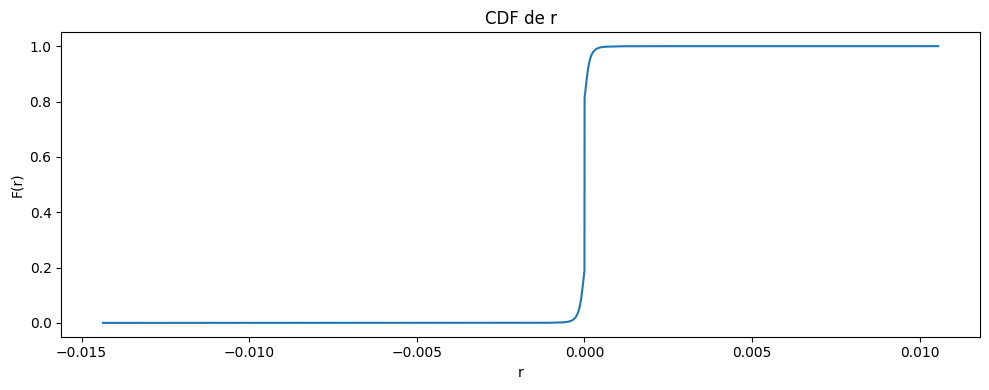

NameError: name 'norm' is not defined

In [ ]:
import numpy as np
from scipy.stats import skew

s = df2["r"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)

# 10 deciles (0.1, 0.2, ..., 0.9)
deciles = {f"d{int(p*10)}": s.quantile(p) for p in np.arange(0.1, 1.0, 0.1)}

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)
print("Deciles:")
for k, v in deciles.items():
    print(k, ":", v)

# TOP Percentiles, permiles, permisiles y fractiles
Percentiles = {f"d{int(p*100)}": s.quantile(p) for p in np.arange(0.95, 1.0, 0.01)}
print("Percentiles mas altos:")
for k, v in Percentiles.items():
    print(k, ":", v)
permiles = {f"p{int(p*1000)}": s.quantile(p)
            for p in np.arange(0.970, 1.001, 0.001)}

print("Permiles")
for k, v in permiles.items():
    print(k, ":", v)

permisiles = {f"p{int(p*10000)}": s.quantile(p)
            for p in np.arange(0.9970, 1.0000, 0.0001)}

print("permisiles")
for k, v in permisiles.items():
    print(k, ":", v)

fractales = {f"p{int(p*100000)}": s.quantile(p)
            for p in np.arange(0.99980, 1.00000, 0.00001)}

print("fractales")
for k, v in fractales.items():
    print(k, ":", v)



import numpy as np
import matplotlib.pyplot as plt

s = df2["r"].dropna().sort_values()

# CDF empírica
y = np.linspace(0, 1, len(s))

plt.figure(figsize=(10,4))
plt.plot(s.values, y)
plt.title("CDF de r")
plt.xlabel("r")
plt.ylabel("F(r)")
plt.tight_layout()
plt.show()



mu = s.mean()
sigma = s.std()

# Rango para graficar
x = np.linspace(s.min(), s.max(), 1000)

# PDF normal
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10,4))
plt.plot(x, pdf, label="Normal PDF", color="red")
plt.title("Función de distribución normal (PDF) ajustada a r")
plt.xlabel("r")
plt.ylabel("densidad")
plt.tight_layout()
plt.show

In [ ]:
# masa central
p0 = (s == 0).mean()
eps = np.nextafter(0, 1)
p0_eps = (np.abs(s) <= eps).mean()
print("P0 (exacto):", p0)
print("P0 (eps):", p0_eps)

deciles = {f"d{int(p*10)}": np.quantile(s, p) for p in np.arange(0.0, 0.5, 0.1)}

for k, v in deciles.items():
    print(k, ":", v)

Percentiles = {f"d{int(p*100)}": np.quantile(s, p) for p in np.arange(0.00, 0.2, 0.001)}
print("Percentiles mas bajos:")
for k, v in Percentiles.items():
    print(k, ":", v)

# permiles = {f"p{int(p*1000)}": np.quantile(s, p)
#             for p in np.arange(0.000, 0.001, 0.0001)}

# print("Permiles")
# for k, v in permiles.items():
#     print(k, ":", v)

# permisiles = {f"p{int(p*10000)}": np.quantile(s, p)
#               for p in np.arange(0.0000, 0.0001, 0.00001)}

# print("permisiles")
# for k, v in permisiles.items():
#     print(k, ":", v)

P0 (exacto): 0.32786400322960957
P0 (eps): 0.32786400322960957
d0 : -0.014359494455016275
d1 : -8.618286599038072e-05
d2 : -2.3295608819751124e-07
d3 : -1.453343688950781e-07
d4 : 0.0
Percentiles mas bajos:
d0 : -0.0003726259123109017
d1 : -0.00027379297534712774
d2 : -0.00022188415403462614
d3 : -0.00018784632101495545
d4 : -0.00016241163877123198
d5 : -0.00014239272740720565
d6 : -0.00012552837490252243
d7 : -0.0001112302457562251
d8 : -9.836824240126419e-05
d9 : -8.725686077916705e-05
d10 : -7.56555983483942e-05
d11 : -6.535197214565614e-05
d12 : -5.694210690674949e-05
d13 : -4.701361152296355e-05
d14 : -3.692890547086236e-05
d15 : -2.9432105400612587e-05
d16 : -1.9270647653613082e-05
d17 : -9.623245827324223e-06
d18 : -9.229650870316999e-07
d19 : -2.3355597196328401e-07


Wavelets serie pura

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df2["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 6)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  6      0.979495          0.020505        0.032527   
1     db6  6      0.979150          0.020850        0.034180   
2    sym6  6      0.979299          0.020701        0.034449   
3    sym4  6      0.979331          0.020669        0.035933   

   mean_abs_acf_level1  entropy_energy          Q_d1  
0             0.003424        1.409305   9579.808015  
1             0.003657        1.408080  10862.384819  
2             0.003602        1.408622  11042.115083  
3             0.003580        1.407631  11599.694393  

Wavelet sugerida: db4 con J = 6

Energía por nivel (J...1) para el mejor wavelet:
[0.00469092 0.00892943 0.01709897 0.0316585  0.0565013  0.09640302]
Shares por nivel (J...1):
[0.02178963 0.04147781 0.07942584 0.14705586 0.26245234 0.44779852]


In [ ]:
#todo mal con serie pura y j=12

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df2["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.839728          0.160272        0.032527   
1     db6  3      0.839351          0.160649        0.034180   
2    sym6  3      0.839914          0.160086        0.034449   
3    sym4  3      0.840089          0.159911        0.035933   

   mean_abs_acf_level1  entropy_energy          Q_d1  
0             0.003424        1.004019   9579.808015  
1             0.003657        1.003136  10862.384819  
2             0.003602        1.004125  11042.115083  
3             0.003580        1.003193  11599.694393  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.0316585  0.0565013  0.09640302]
Shares por nivel (J...1):
[0.17153238 0.30613587 0.52233175]


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df2["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 2)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  2      0.695687          0.304313        0.032527   
1     db6  2      0.695790          0.304210        0.034180   
2    sym6  2      0.695019          0.304981        0.034449   
3    sym4  2      0.695401          0.304599        0.035933   

   mean_abs_acf_level1  entropy_energy          Q_d1  
0             0.003424        0.658700   9579.808015  
1             0.003657        0.658182  10862.384819  
2             0.003602        0.657748  11042.115083  
3             0.003580        0.656933  11599.694393  

Wavelet sugerida: db4 con J = 2

Energía por nivel (J...1) para el mejor wavelet:
[0.0565013  0.09640302]
Shares por nivel (J...1):
[0.36952062 0.63047938]


In [ ]:
# Positivo: Q bajo harto 25K A 9K, buena estructura de energia y entropia. Asi cayo tambien acf pero levemente
# malo: nivel uno con mucha energia todavia

# j 6: mejorcita
# J 3: mejora en entropia, acf1 alto pero un buen Q
# J 2: se cae.

# DB64 es la campeona absoluta, pero debe ser TRUCADA R_2

## r_3

In [ ]:
df3 = vp_btc.iloc[:, [0, 1, 2, 3, 4, 20]]
df3 = df3.iloc[::3].copy()
df3["r"] = df3["close_ln"].diff()
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10540800 entries, 0 to 31622397
Data columns (total 6 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   VB90s     float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 482.5 MB


Media: 7.536195464797657e-08
Mediana: 0.0
Moda: 0.0
Desvío estándar: 0.00014878988051155622
Skew: -0.26902719436568956
Deciles:
d1 : -0.00012042308461452931
d2 : -2.806013259437634e-05
d3 : -1.547034607085606e-07
d4 : 0.0
d5 : 0.0
d6 : 0.0
d7 : 1.548275090357265e-07
d8 : 2.931249013471416e-05
d9 : 0.00012094379181135652
Percentiles mas altos:
d95 : 0.00020662055763303043
d96 : 0.000236442646780688
d97 : 0.0002759990293719386
d98 : 0.0003330670441356176
d99 : 0.00044169980694757445
d100 : 0.010947838398607246
Permiles
p970 : 0.0002759990293719386
p971 : 0.00028079763666212444
p972 : 0.00028565215177506784
p973 : 0.0002906470229357472
p974 : 0.00029585543230169214
p975 : 0.0003005923059247626
p976 : 0.0003065460041478472
p977 : 0.00031275091785919765
p978 : 0.00031914179130220085
p979 : 0.0003260208837757651
p980 : 0.0003330670441356176
p981 : 0.00034091345220467413
p982 : 0.0003489518616128961
p983 : 0.0003574570607878336
p984 : 0.0003664052677325188
p985 : 0.0003764834023326275
p986 : 

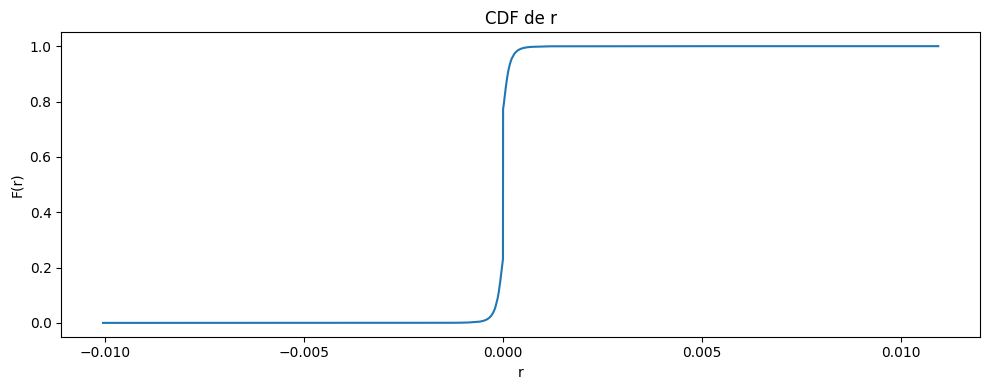

NameError: name 'norm' is not defined

In [ ]:
import numpy as np
from scipy.stats import skew

s = df3["r"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)

# 10 deciles (0.1, 0.2, ..., 0.9)
deciles = {f"d{int(p*10)}": s.quantile(p) for p in np.arange(0.1, 1.0, 0.1)}

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)
print("Deciles:")
for k, v in deciles.items():
    print(k, ":", v)

# TOP Percentiles, permiles, permisiles y fractiles
Percentiles = {f"d{int(p*100)}": s.quantile(p) for p in np.arange(0.95, 1.0, 0.01)}
print("Percentiles mas altos:")
for k, v in Percentiles.items():
    print(k, ":", v)
permiles = {f"p{int(p*1000)}": s.quantile(p)
            for p in np.arange(0.970, 1.001, 0.001)}

print("Permiles")
for k, v in permiles.items():
    print(k, ":", v)

permisiles = {f"p{int(p*10000)}": s.quantile(p)
            for p in np.arange(0.9970, 1.0000, 0.0001)}

print("permisiles")
for k, v in permisiles.items():
    print(k, ":", v)

fractales = {f"p{int(p*100000)}": s.quantile(p)
            for p in np.arange(0.99980, 1.00000, 0.00001)}

print("fractales")
for k, v in fractales.items():
    print(k, ":", v)



import numpy as np
import matplotlib.pyplot as plt

s = df3["r"].dropna().sort_values()

# CDF empírica
y = np.linspace(0, 1, len(s))

plt.figure(figsize=(10,4))
plt.plot(s.values, y)
plt.title("CDF de r")
plt.xlabel("r")
plt.ylabel("F(r)")
plt.tight_layout()
plt.show()



mu = s.mean()
sigma = s.std()

# Rango para graficar
x = np.linspace(s.min(), s.max(), 1000)

# PDF normal
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10,4))
plt.plot(x, pdf, label="Normal PDF", color="red")
plt.title("Función de distribución normal (PDF) ajustada a r")
plt.xlabel("r")
plt.ylabel("densidad")
plt.tight_layout()
plt.show

In [ ]:
# masa central
p0 = (s == 0).mean()
eps = np.nextafter(0, 1)
p0_eps = (np.abs(s) <= eps).mean()
print("P0 (exacto):", p0)
print("P0 (eps):", p0_eps)

deciles = {f"d{int(p*10)}": np.quantile(s, p) for p in np.arange(0.0, 0.5, 0.1)}

for k, v in deciles.items():
    print(k, ":", v)

Percentiles = {f"d{int(p*100)}": np.quantile(s, p) for p in np.arange(0.00, 0.2, 0.001)}
print("Percentiles mas bajos:")
for k, v in Percentiles.items():
    print(k, ":", v)

# permiles = {f"p{int(p*1000)}": np.quantile(s, p)
#             for p in np.arange(0.000, 0.001, 0.0001)}

# print("Permiles")
# for k, v in permiles.items():
#     print(k, ":", v)

# permisiles = {f"p{int(p*10000)}": np.quantile(s, p)
#               for p in np.arange(0.0000, 0.0001, 0.00001)}

# print("permisiles")
# for k, v in permisiles.items():
#     print(k, ":", v)

P0 (exacto): 0.2813089406220534
P0 (eps): 0.2813089406220534
d0 : -0.010059675135625668
d1 : -0.00012042308461452931
d2 : -2.806013259437634e-05
d3 : -1.547034607085606e-07
d4 : 0.0
Percentiles mas bajos:
d0 : -0.0004613437276974963
d1 : -0.0003415415069741208
d2 : -0.00028119820642504223
d3 : -0.00024007248462635288
d4 : -0.00020925828485002994
d5 : -0.00018555170760770068
d6 : -0.00016576090989919122
d7 : -0.00014923368481931475
d8 : -0.0001342721578387227
d9 : -0.0001215641849435478
d10 : -0.0001096641231991633
d11 : -9.889728098328376e-05
d12 : -8.926048136505216e-05
d13 : -7.952925642604568e-05
d14 : -6.958336147961575e-05
d15 : -6.139206795540987e-05
d16 : -5.337222061856649e-05
d17 : -4.450320033410194e-05
d18 : -3.5377633128078404e-05
d19 : -2.8864728014237738e-05


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df3["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 6)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  6      0.980507          0.019493        0.037415   
1     db6  6      0.980815          0.019185        0.038749   
2    sym6  6      0.980675          0.019325        0.039246   
3    sym4  6      0.980604          0.019396        0.040173   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003161        1.391464  7752.784097  
1             0.003217        1.392028  8295.651313  
2             0.003316        1.392372  8524.470548  
3             0.003296        1.391119  8867.621533  

Wavelet sugerida: db4 con J = 6

Energía por nivel (J...1) para el mejor wavelet:
[0.0045904  0.00918397 0.01753507 0.03259351 0.0604063  0.10449865]
Shares por nivel (J...1):
[0.02006224 0.04013833 0.07663663 0.14244926 0.26400446 0.45670909]


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df3["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.846337          0.153663        0.037415   
1     db6  3      0.846405          0.153595        0.038749   
2    sym6  3      0.846124          0.153876        0.039246   
3    sym4  3      0.846383          0.153617        0.040173   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003161        0.996463  7752.784097  
1             0.003217        0.996517  8295.651313  
2             0.003316        0.996791  8524.470548  
3             0.003296        0.995971  8867.621533  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.03259351 0.0604063  0.10449865]
Shares por nivel (J...1):
[0.16503174 0.30585709 0.52911118]


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df3["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 2)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  2      0.706665          0.293335        0.037415   
1     db6  2      0.706130          0.293870        0.038749   
2    sym6  2      0.705136          0.294864        0.039246   
3    sym4  2      0.705617          0.294383        0.040173   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003161        0.656962  7752.784097  
1             0.003217        0.656222  8295.651313  
2             0.003316        0.655521  8524.470548  
3             0.003296        0.654896  8867.621533  

Wavelet sugerida: db4 con J = 2

Energía por nivel (J...1) para el mejor wavelet:
[0.0604063  0.10449865]
Shares por nivel (J...1):
[0.36630983 0.63369017]


In [ ]:
# J6 siempre el mejor.
# Evolucionn de los mejores por entropia y frecuencia temporal:
# - r₁ truncado → Q ≈ 25.000
# - r₂ puro → Q ≈ 9.580
# - r₃ puro → Q ≈ 7.752

# A medida que se agregan segundos, el ruido de microestructura desaparece más
# rápido que la dinámica real del precio → whiteness mejora.

# DB4 CAMPEONA ABSOLUTA AL IGUAL QUE EN R_2 PURA (QUE ES MEJOR QUE R_2 TRUNC)

# ES EL MEJOR EN WHITENESS, ENTROPIA, MANTIENE ASIMETRIA, PERO HAY UN POCO DE AUTOCORRELACION DE MAS

## r_5


In [ ]:
df5 = vp_btc.iloc[:, [0, 1, 2, 3, 4, 20]]
df5 = df5.iloc[::5].copy()
df5["r"] = df5["close_ln"].diff()
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6324480 entries, 0 to 31622395
Data columns (total 6 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   VB90s     float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 289.5 MB


Media: 1.25603265690571e-07
Mediana: 0.0
Moda: 0.0
Desvío estándar: 0.00019855457352692087
Skew: -0.40834499325405255
Deciles:
d1 : -0.00017222389268987116
d2 : -6.859676887849275e-05
d3 : -2.1105924652431435e-07
d4 : 0.0
d5 : 0.0
d6 : 0.0
d7 : 2.077574510650489e-07
d8 : 6.932498129330615e-05
d9 : 0.00017277186968485126
Percentiles mas altos:
d95 : 0.0002812700723461958
d96 : 0.00031732933942947735
d97 : 0.0003665399943378135
d98 : 0.0004396937377519791
d99 : 0.0005776129701509085
d100 : 0.015451702569313497
Permiles
p970 : 0.0003665399943378135
p971 : 0.0003725686136276779
p972 : 0.000378945390521664
p973 : 0.0003854432825619723
p974 : 0.00039181474361512075
p975 : 0.0003988269326985257
p976 : 0.00040587727329213406
p977 : 0.0004136872350629731
p978 : 0.0004218373307861896
p979 : 0.0004305074507235906
p980 : 0.0004396937377519791
p981 : 0.00044954259129948186
p982 : 0.00045967398501489416
p983 : 0.00047038260175317955
p984 : 0.00048182564501215563
p985 : 0.0004944025489337456
p986 : 0

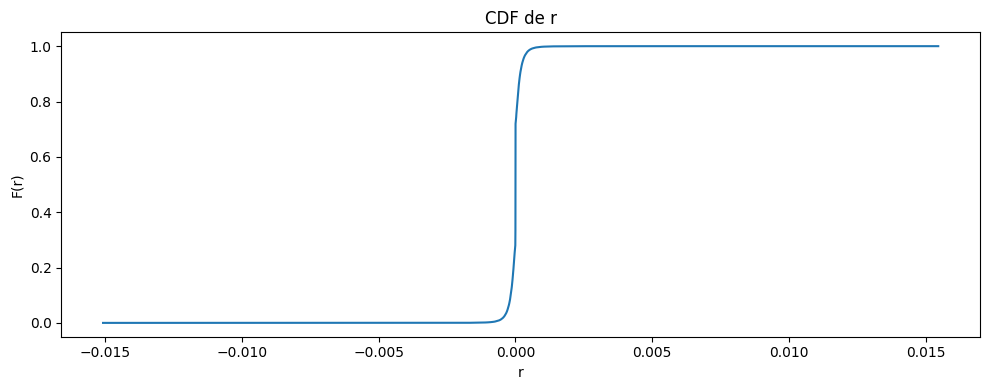

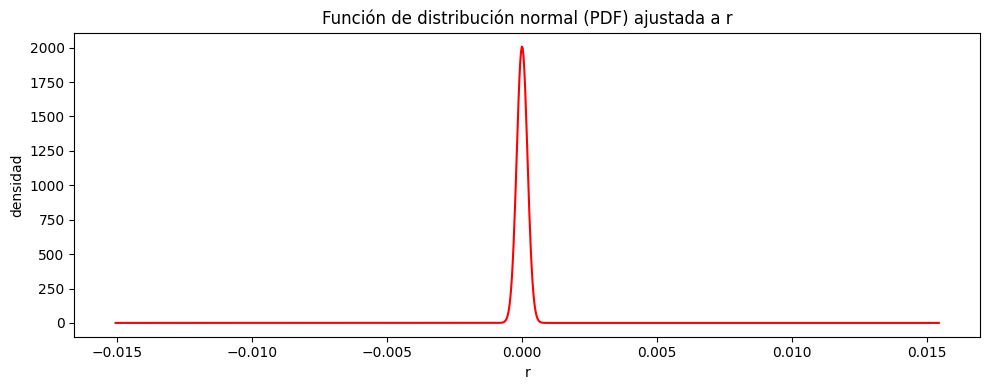

In [ ]:
import numpy as np
from scipy.stats import skew, norm

s = df5["r"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)

# 10 deciles (0.1, 0.2, ..., 0.9)
deciles = {f"d{int(p*10)}": s.quantile(p) for p in np.arange(0.1, 1.0, 0.1)}

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)
print("Deciles:")
for k, v in deciles.items():
    print(k, ":", v)

# TOP Percentiles, permiles, permisiles y fractiles
Percentiles = {f"d{int(p*100)}": s.quantile(p) for p in np.arange(0.95, 1.0, 0.01)}
print("Percentiles mas altos:")
for k, v in Percentiles.items():
    print(k, ":", v)
permiles = {f"p{int(p*1000)}": s.quantile(p)
            for p in np.arange(0.970, 1.001, 0.001)}

print("Permiles")
for k, v in permiles.items():
    print(k, ":", v)

permisiles = {f"p{int(p*10000)}": s.quantile(p)
            for p in np.arange(0.9970, 1.0000, 0.0001)}

print("permisiles")
for k, v in permisiles.items():
    print(k, ":", v)

fractales = {f"p{int(p*100000)}": s.quantile(p)
            for p in np.arange(0.99980, 1.00000, 0.00001)}

print("fractales")
for k, v in fractales.items():
    print(k, ":", v)



import numpy as np
import matplotlib.pyplot as plt

s = df5["r"].dropna().sort_values()

# CDF empírica
y = np.linspace(0, 1, len(s))

plt.figure(figsize=(10,4))
plt.plot(s.values, y)
plt.title("CDF de r")
plt.xlabel("r")
plt.ylabel("F(r)")
plt.tight_layout()
plt.show()



mu = s.mean()
sigma = s.std()

# Rango para graficar
x = np.linspace(s.min(), s.max(), 1000)

# PDF normal
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10,4))
plt.plot(x, pdf, label="Normal PDF", color="red")
plt.title("Función de distribución normal (PDF) ajustada a r")
plt.xlabel("r")
plt.ylabel("densidad")
plt.tight_layout()
plt.show()

In [ ]:
# masa central
p0 = (s == 0).mean()
eps = np.nextafter(0, 1)
p0_eps = (np.abs(s) <= eps).mean()
print("P0 (exacto):", p0)
print("P0 (eps):", p0_eps)

deciles = {f"d{int(p*10)}": np.quantile(s, p) for p in np.arange(0.0, 0.5, 0.1)}

for k, v in deciles.items():
    print(k, ":", v)

Percentiles = {f"d{int(p*100)}": np.quantile(s, p) for p in np.arange(0.00, 0.2, 0.001)}
print("Percentiles mas bajos:")
for k, v in Percentiles.items():
    print(k, ":", v)

# permiles = {f"p{int(p*1000)}": np.quantile(s, p)
#             for p in np.arange(0.000, 0.001, 0.0001)}

# print("Permiles")
# for k, v in permiles.items():
#     print(k, ":", v)

# permisiles = {f"p{int(p*10000)}": np.quantile(s, p)
#               for p in np.arange(0.0000, 0.0001, 0.00001)}

# print("permisiles")
# for k, v in permisiles.items():
#     print(k, ":", v)

P0 (exacto): 0.22124605046518456
P0 (eps): 0.22124605046518456
d0 : -0.015071247667211907
d1 : -0.00017222389268987116
d2 : -6.859676887849275e-05
d3 : -2.1105924652431435e-07
d4 : 0.0
Percentiles mas bajos:
d0 : -0.0005994356037147135
d1 : -0.00044995414701337567
d2 : -0.00037286906594938783
d3 : -0.0003213199486267584
d4 : -0.0002843258780083175
d5 : -0.0002537362750797101
d6 : -0.0002288797924044452
d7 : -0.0002074669847735642
d8 : -0.0001895697789652857
d9 : -0.0001736562873561418
d10 : -0.00015913140717299613
d11 : -0.00014655146592651392
d12 : -0.0001344465297267341
d13 : -0.0001237461308896428
d14 : -0.00011400407252855162
d15 : -0.00010359990943791786
d16 : -9.511638335760959e-05
d17 : -8.70921121034769e-05
d18 : -7.819888760190708e-05
d19 : -6.934822144280873e-05


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df5["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 6)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  6      0.981971          0.018029        0.013217   
1    sym6  6      0.982052          0.017948        0.020884   
2     db6  6      0.982099          0.017901        0.020906   
3    sym4  6      0.982064          0.017936        0.022173   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.002907        1.370935  1220.629673  
1             0.003318        1.369313  2115.544851  
2             0.003289        1.368965  2164.453623  
3             0.003342        1.367872  2234.346584  

Wavelet sugerida: db4 con J = 6

Energía por nivel (J...1) para el mejor wavelet:
[0.00460989 0.00911141 0.01817454 0.03408218 0.06414813 0.1147143 ]
Shares por nivel (J...1):
[0.01882814 0.03721365 0.07423013 0.13920158 0.26199973 0.46852676]


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df5["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.854047          0.145953        0.013217   
1    sym6  3      0.854492          0.145508        0.020884   
2     db6  3      0.854113          0.145887        0.020906   
3    sym4  3      0.854634          0.145366        0.022173   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.002907        0.987935  1220.629673  
1             0.003318        0.986468  2115.544851  
2             0.003289        0.985231  2164.453623  
3             0.003342        0.985100  2234.346584  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.03408218 0.06414813 0.1147143 ]
Shares por nivel (J...1):
[0.16005184 0.30124327 0.53870488]


In [ ]:
# J6 confirmada. En este caso sym4 es la mejor
#  - Q cae exponencialmente
#  . la acf maxima sube pero sigue siendo muy buena 0.0077
#  - acf abs mean = 0.00328 menor que o.oo5 excelente, muy limpio
#  - crecimeinto suave y no degenerado en energy_ratio
#  - entropia evolucion:
#   r₁ truncado → ~85–92% (ruido)
#   r₂ puro → ~80%
#   r₃ puro → ~77%
#   r₅ → ~72%
#   - SE ELIMINO LA MICROESTRUCTURA

## r_10 *


In [ ]:
df10 = vp_btc.iloc[:, [0, 1, 2, 3, 4, 20]]
df10 = df10.iloc[::10].copy()
df10["r"] = df10["close_ln"].diff()
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3162240 entries, 0 to 31622390
Data columns (total 6 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   VB90s     float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 144.8 MB


Media: 2.5120653730677365e-07
Mediana: 0.0
Moda: 0.0
Desvío estándar: 0.000290376799758221
Skew: -0.6644163965928828
Deciles:
d1 : -0.00026676758983050773
d2 : -0.00012998375213797424
d3 : -4.888213497800108e-05
d4 : -1.5214678050767816e-07
d5 : 0.0
d6 : 1.5112582580911745e-07
d7 : 4.940751749771264e-05
d8 : 0.00013040859643567173
d9 : 0.00026780246966211566
Percentiles mas altos:
d95 : 0.00041478295868806436
d96 : 0.0004653834598781969
d97 : 0.0005335308049401632
d98 : 0.0006348627043620058
d99 : 0.00082801840637032
d100 : 0.01430715525476245
Permiles
p970 : 0.0005335308049401632
p971 : 0.000541870576748817
p972 : 0.0005504572842127686
p973 : 0.0005592279938695307
p974 : 0.0005682853087387143
p975 : 0.0005778918045185033
p976 : 0.0005881440891452153
p977 : 0.0005988980718875149
p978 : 0.0006100198064358578
p979 : 0.0006219765619111564
p980 : 0.0006348627043620058
p981 : 0.0006483678177292883
p982 : 0.0006626566118075346
p983 : 0.0006780131169875573
p984 : 0.000694884315670125
p985 : 0

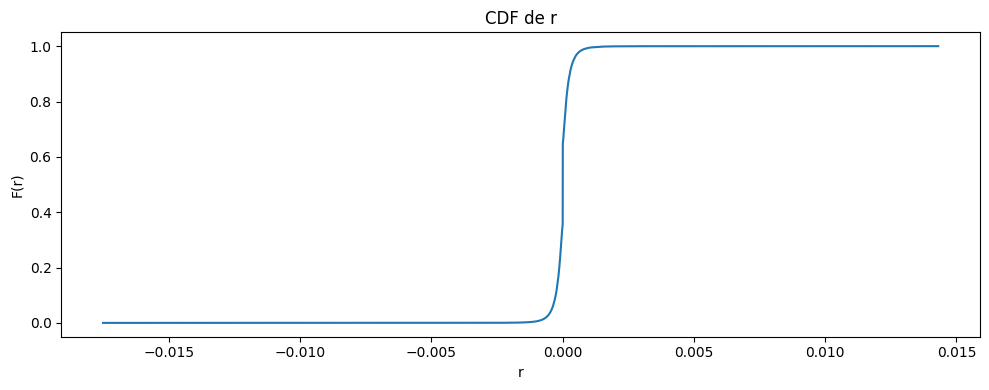

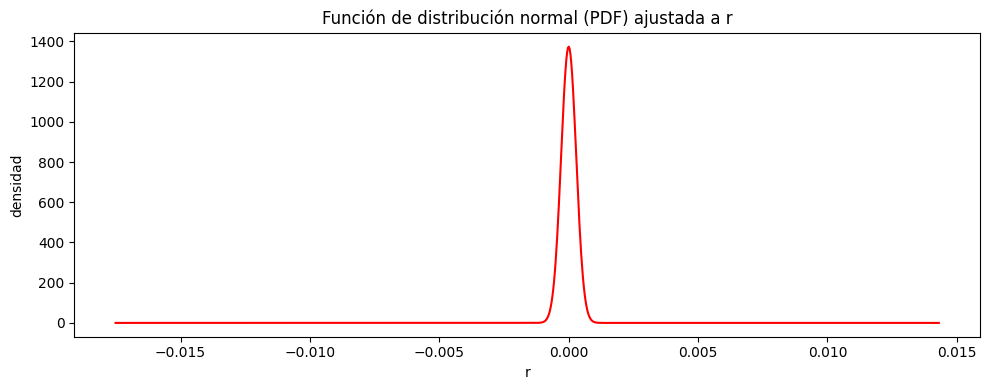

In [ ]:
import numpy as np
from scipy.stats import skew, norm

s = df10["r"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)

# 10 deciles (0.1, 0.2, ..., 0.9)
deciles = {f"d{int(p*10)}": s.quantile(p) for p in np.arange(0.1, 1.0, 0.1)}

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)
print("Deciles:")
for k, v in deciles.items():
    print(k, ":", v)

# TOP Percentiles, permiles, permisiles y fractiles
Percentiles = {f"d{int(p*100)}": s.quantile(p) for p in np.arange(0.95, 1.0, 0.01)}
print("Percentiles mas altos:")
for k, v in Percentiles.items():
    print(k, ":", v)
permiles = {f"p{int(p*1000)}": s.quantile(p)
            for p in np.arange(0.970, 1.001, 0.001)}

print("Permiles")
for k, v in permiles.items():
    print(k, ":", v)

permisiles = {f"p{int(p*10000)}": s.quantile(p)
            for p in np.arange(0.9970, 1.0000, 0.0001)}

print("permisiles")
for k, v in permisiles.items():
    print(k, ":", v)

fractales = {f"p{int(p*100000)}": s.quantile(p)
            for p in np.arange(0.99980, 1.00000, 0.00001)}

print("fractales")
for k, v in fractales.items():
    print(k, ":", v)



import numpy as np
import matplotlib.pyplot as plt

s = df10["r"].dropna().sort_values()

# CDF empírica
y = np.linspace(0, 1, len(s))

plt.figure(figsize=(10,4))
plt.plot(s.values, y)
plt.title("CDF de r")
plt.xlabel("r")
plt.ylabel("F(r)")
plt.tight_layout()
plt.show()



mu = s.mean()
sigma = s.std()

# Rango para graficar
x = np.linspace(s.min(), s.max(), 1000)

# PDF normal
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10,4))
plt.plot(x, pdf, label="Normal PDF", color="red")
plt.title("Función de distribución normal (PDF) ajustada a r")
plt.xlabel("r")
plt.ylabel("densidad")
plt.tight_layout()
plt.show()

In [ ]:
# masa central
p0 = (s == 0).mean()
eps = np.nextafter(0, 1)
p0_eps = (np.abs(s) <= eps).mean()
print("P0 (exacto):", p0)
print("P0 (eps):", p0_eps)

deciles = {f"d{int(p*10)}": np.quantile(s, p) for p in np.arange(0.0, 0.5, 0.1)}

for k, v in deciles.items():
    print(k, ":", v)

Percentiles = {f"d{int(p*100)}": np.quantile(s, p) for p in np.arange(0.00, 0.2, 0.001)}
print("Percentiles mas bajos:")
for k, v in Percentiles.items():
    print(k, ":", v)

# permiles = {f"p{int(p*1000)}": np.quantile(s, p)
#             for p in np.arange(0.000, 0.001, 0.0001)}

# print("Permiles")
# for k, v in permiles.items():
#     print(k, ":", v)

# permisiles = {f"p{int(p*10000)}": np.quantile(s, p)
#               for p in np.arange(0.0000, 0.0001, 0.00001)}

# print("permisiles")
# for k, v in permisiles.items():
#     print(k, ":", v)

P0 (exacto): 0.1040912948216904
P0 (eps): 0.1040912948216904
d0 : -0.02270720738637877
d1 : -0.0003371947044797707
d2 : -0.0001732940764942015
d3 : -8.093561576139052e-05
d4 : -2.400407861813392e-07
Percentiles mas bajos:
d0 : -0.0010524389561297482
d1 : -0.000798699366188714
d2 : -0.000668114432760035
d3 : -0.000582131826901005
d4 : -0.0005192846253105614
d5 : -0.00047030662868812807
d6 : -0.0004299274431113105
d7 : -0.00039582443766040143
d8 : -0.0003657379544529
d9 : -0.0003397565633194226
d10 : -0.0003161667496839229
d11 : -0.0002952106950851245
d12 : -0.00027621478841250634
d13 : -0.0002581737193119658
d14 : -0.00024143300978510143
d15 : -0.00022618347367818356
d16 : -0.0002116719089413621
d17 : -0.00019894742109004683
d18 : -0.00018618756073452404
d19 : -0.00017440182492616427


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df10["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.863120          0.136880        0.018851   
1    sym6  3      0.862229          0.137771        0.028615   
2     db6  3      0.862821          0.137179        0.029370   
3    sym4  3      0.862455          0.137545        0.029773   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003114        0.980421   788.172962  
1             0.003599        0.976053  1527.291776  
2             0.003750        0.976940  1623.675248  
3             0.003572        0.974309  1625.363930  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.0357418  0.06868754 0.12570952]
Shares por nivel (J...1):
[0.15530536 0.29846131 0.54623333]


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df10["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 6)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  6      0.983487          0.016513        0.018851   
1    sym6  6      0.983535          0.016465        0.028615   
2     db6  6      0.983684          0.016316        0.029370   
3    sym4  6      0.983506          0.016494        0.029773   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003114        1.349098   788.172962  
1             0.003599        1.346415  1527.291776  
2             0.003750        1.346673  1623.675248  
3             0.003572        1.344478  1625.363930  

Wavelet sugerida: db4 con J = 6

Energía por nivel (J...1) para el mejor wavelet:
[0.00458471 0.00918803 0.01832132 0.0357418  0.06868754 0.12570952]
Shares por nivel (J...1):
[0.01748336 0.03503767 0.06986659 0.13629791 0.26193334 0.47938114]


## r_15 **


In [ ]:
df15 = vp_btc.iloc[:, [0, 1, 2, 3, 4, 20]]
df15 = df15.iloc[::15].copy()
df15["r"] = df15["close_ln"].diff()
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 6 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   VB90s     float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 96.5 MB


Media: 3.76809916230909e-07
Mediana: 0.0
Moda: 0.0
Desvío estándar: 0.00036078789699599685
Skew: -0.5918241943710671
Deciles:
d1 : -0.0003371947044797707
d2 : -0.0001732940764942015
d3 : -8.093561576139052e-05
d4 : -2.400407861813392e-07
d5 : 0.0
d6 : 2.3319833459822805e-07
d7 : 8.111270573536418e-05
d8 : 0.00017403621973635124
d9 : 0.0003386397390165995
Percentiles mas altos:
d95 : 0.000516697122034948
d96 : 0.0005783330969144623
d97 : 0.0006613860042640953
d98 : 0.0007849116275486496
d99 : 0.00102082375687722
d100 : 0.019740671452751712
Permiles
p970 : 0.0006613860042640953
p971 : 0.0006712843939121873
p972 : 0.0006818457931035193
p973 : 0.0006923294869505018
p974 : 0.0007035229648896201
p975 : 0.000715536563801589
p976 : 0.0007285188955464288
p977 : 0.0007417317042810429
p978 : 0.0007551259786533746
p979 : 0.0007697478319800725
p980 : 0.0007849116275486496
p981 : 0.0008006253623015165
p982 : 0.0008188651597057585
p983 : 0.0008375312170303781
p984 : 0.0008576397359220929
p985 : 0.000

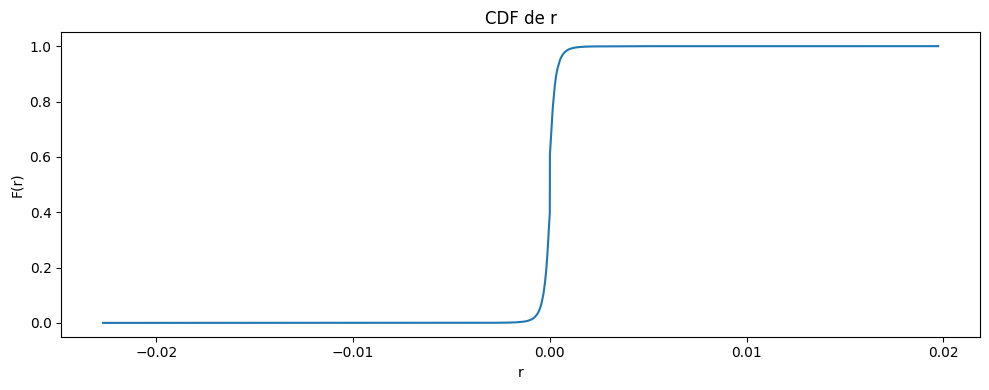

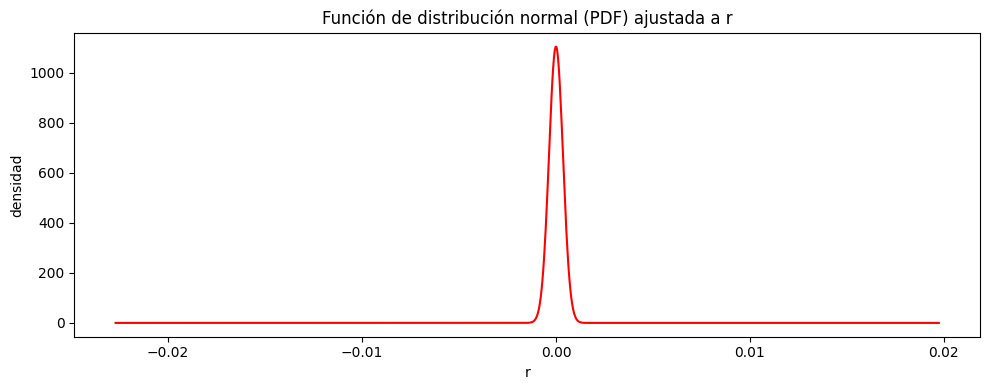

In [ ]:
import numpy as np
from scipy.stats import skew, norm

s = df15["r"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)

# 10 deciles (0.1, 0.2, ..., 0.9)
deciles = {f"d{int(p*10)}": s.quantile(p) for p in np.arange(0.1, 1.0, 0.1)}

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)
print("Deciles:")
for k, v in deciles.items():
    print(k, ":", v)

# TOP Percentiles, permiles, permisiles y fractiles
Percentiles = {f"d{int(p*100)}": s.quantile(p) for p in np.arange(0.95, 1.0, 0.01)}
print("Percentiles mas altos:")
for k, v in Percentiles.items():
    print(k, ":", v)
permiles = {f"p{int(p*1000)}": s.quantile(p)
            for p in np.arange(0.970, 1.001, 0.001)}

print("Permiles")
for k, v in permiles.items():
    print(k, ":", v)

permisiles = {f"p{int(p*10000)}": s.quantile(p)
            for p in np.arange(0.9970, 1.0000, 0.0001)}

print("permisiles")
for k, v in permisiles.items():
    print(k, ":", v)

fractales = {f"p{int(p*100000)}": s.quantile(p)
            for p in np.arange(0.99980, 1.00000, 0.00001)}

print("fractales")
for k, v in fractales.items():
    print(k, ":", v)



import numpy as np
import matplotlib.pyplot as plt

s = df15["r"].dropna().sort_values()

# CDF empírica
y = np.linspace(0, 1, len(s))

plt.figure(figsize=(10,4))
plt.plot(s.values, y)
plt.title("CDF de r")
plt.xlabel("r")
plt.ylabel("F(r)")
plt.tight_layout()
plt.show()



mu = s.mean()
sigma = s.std()

# Rango para graficar
x = np.linspace(s.min(), s.max(), 1000)

# PDF normal
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10,4))
plt.plot(x, pdf, label="Normal PDF", color="red")
plt.title("Función de distribución normal (PDF) ajustada a r")
plt.xlabel("r")
plt.ylabel("densidad")
plt.tight_layout()
plt.show()

In [ ]:
# masa central
p0 = (s == 0).mean()
eps = np.nextafter(0, 1)
p0_eps = (np.abs(s) <= eps).mean()
print("P0 (exacto):", p0)
print("P0 (eps):", p0_eps)

deciles = {f"d{int(p*10)}": np.quantile(s, p) for p in np.arange(0.0, 0.5, 0.1)}

for k, v in deciles.items():
    print(k, ":", v)

Percentiles = {f"d{int(p*100)}": np.quantile(s, p) for p in np.arange(0.00, 0.2, 0.001)}
print("Percentiles mas bajos:")
for k, v in Percentiles.items():
    print(k, ":", v)

# permiles = {f"p{int(p*1000)}": np.quantile(s, p)
#             for p in np.arange(0.000, 0.001, 0.0001)}

# print("Permiles")
# for k, v in permiles.items():
#     print(k, ":", v)

# permisiles = {f"p{int(p*10000)}": np.quantile(s, p)
#               for p in np.arange(0.0000, 0.0001, 0.00001)}

# print("permisiles")
# for k, v in permisiles.items():
#     print(k, ":", v)

P0 (exacto): 0.1040912948216904
P0 (eps): 0.1040912948216904
d0 : -0.02270720738637877
d1 : -0.0003371947044797707
d2 : -0.0001732940764942015
d3 : -8.093561576139052e-05
d4 : -2.400407861813392e-07
Percentiles mas bajos:
d0 : -0.0010524389561297482
d1 : -0.000798699366188714
d2 : -0.000668114432760035
d3 : -0.000582131826901005
d4 : -0.0005192846253105614
d5 : -0.00047030662868812807
d6 : -0.0004299274431113105
d7 : -0.00039582443766040143
d8 : -0.0003657379544529
d9 : -0.0003397565633194226
d10 : -0.0003161667496839229
d11 : -0.0002952106950851245
d12 : -0.00027621478841250634
d13 : -0.0002581737193119658
d14 : -0.00024143300978510143
d15 : -0.00022618347367818356
d16 : -0.0002116719089413621
d17 : -0.00019894742109004683
d18 : -0.00018618756073452404
d19 : -0.00017440182492616427


wavelet

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df15["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.867754          0.132246        0.010111   
1    sym6  3      0.867436          0.132564        0.027775   
2    sym4  3      0.867674          0.132326        0.029308   
3     db6  3      0.867601          0.132399        0.030858   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003614        0.969032   430.287597  
1             0.004873        0.963715  1241.829204  
2             0.004746        0.961043  1270.757320  
3             0.005486        0.960648  1573.084635  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.03457333 0.07175279 0.13179832]
Shares por nivel (J...1):
[0.14519017 0.30132476 0.55348506]


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df15["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 6)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  6      0.984283          0.015717        0.010111   
1    sym6  6      0.984193          0.015807        0.027775   
2    sym4  6      0.984177          0.015823        0.029308   
3     db6  6      0.984326          0.015674        0.030858   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003614        1.330457   430.287597  
1             0.004873        1.326638  1241.829204  
2             0.004746        1.323769  1270.757320  
3             0.005486        1.324153  1573.084635  

Wavelet sugerida: db4 con J = 6

Energía por nivel (J...1) para el mejor wavelet:
[0.0044936  0.0090157  0.01846812 0.03457333 0.07175279 0.13179832]
Shares por nivel (J...1):
[0.0166367  0.03337887 0.06837465 0.12800108 0.26565086 0.48795784]


# CONCULSIONES

Top 3 (lo mejor de todo el recorrido)

# CVS

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


SAVE

In [ ]:
# Montar Google Drive
drive.mount('/content/drive')

# Ruta donde querés guardar el archivo (podés cambiar el nombre o carpeta)
ruta_guardado = '/content/drive/MyDrive/VFJmf1.parquet'

# Guardar en formato Parquet, conservando la estructura y tipos
mf1.to_parquet(ruta_guardado, index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


APERTURA

In [ ]:
mf1 = pd.read_parquet('/content/drive/MyDrive/VFmf1.parquet')

KeyboardInterrupt: 

In [ ]:
mf1.info()